# FakeOut — Fake Rental Listing Prediction

**Final project for ML.** Goal: build a fraud detector for rental listings using the UCI Apartment Listings dataset (~99K rows). The pipeline:

1. **EDA + feature engineering** — price-per-sqft, amenity counts, geographic cleanup
2. **Zillow ZORI integration** — pair each listing with a market-rent baseline via direct ZIP match + spatial k-NN fallback
3. **Effective-price extraction** — parse body text to recover real prices when the listing only stores a building's floor price
4. **Snorkel weak supervision** — programmatic labeling functions vote on each listing; a generative `LabelModel` produces soft labels
5. **Hand-labeling for ground truth** — 165 stratified hand-labeled listings reveal that LF design choices interact with dataset structure to produce a "legitimate-listing detector" rather than a fraud detector
6. **Discriminative model on weak labels** — fails because it inherits the LF biases
7. **Ground-truth supervised baseline (LOOCV)** — wins decisively, demonstrating that *for this dataset* a small amount of ground truth beats a large amount of weak supervision

**Headline result**: hand-supervised LOOCV achieves AUROC 0.82 vs. 0.45 for Snorkel and 0.33 for the GBM-on-weak-labels — a clean negative result for naive weak-supervision pipelines on imbalanced, aggregator-heavy data.

## Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

### Loading Our Data

In [2]:
# Load the data
df = pd.read_csv("apartments_for_rent_classified_100K.csv", encoding='latin-1', on_bad_lines='skip', delimiter=';')

# Set display options to show all columns and adjust width
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

/var/folders/kv/s43skrtj28xgrn72fc1vv5lw0000gn/T/ipykernel_73041/3502588502.py:2: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("apartments_for_rent_classified_100K.csv", encoding='latin-1', on_bad_lines='skip', delimiter=';')


### What is in the data?

In [3]:
print(df.shape)
df.head()


(99492, 22)


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  str    
 2   title          99492 non-null  str    
 3   body           99492 non-null  str    
 4   amenities      83448 non-null  str    
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  str    
 8   fee            99492 non-null  str    
 9   has_photo      99492 non-null  str    
 10  pets_allowed   39068 non-null  str    
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  str    
 13  price_type     99492 non-null  str    
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   str    
 16  cityname       99190 non-null  str    
 17  state          99190 non-null  str    
 18  latitude       99

We have 99492 rows with 22 columns which is a good sized dataset.

### Missing Values

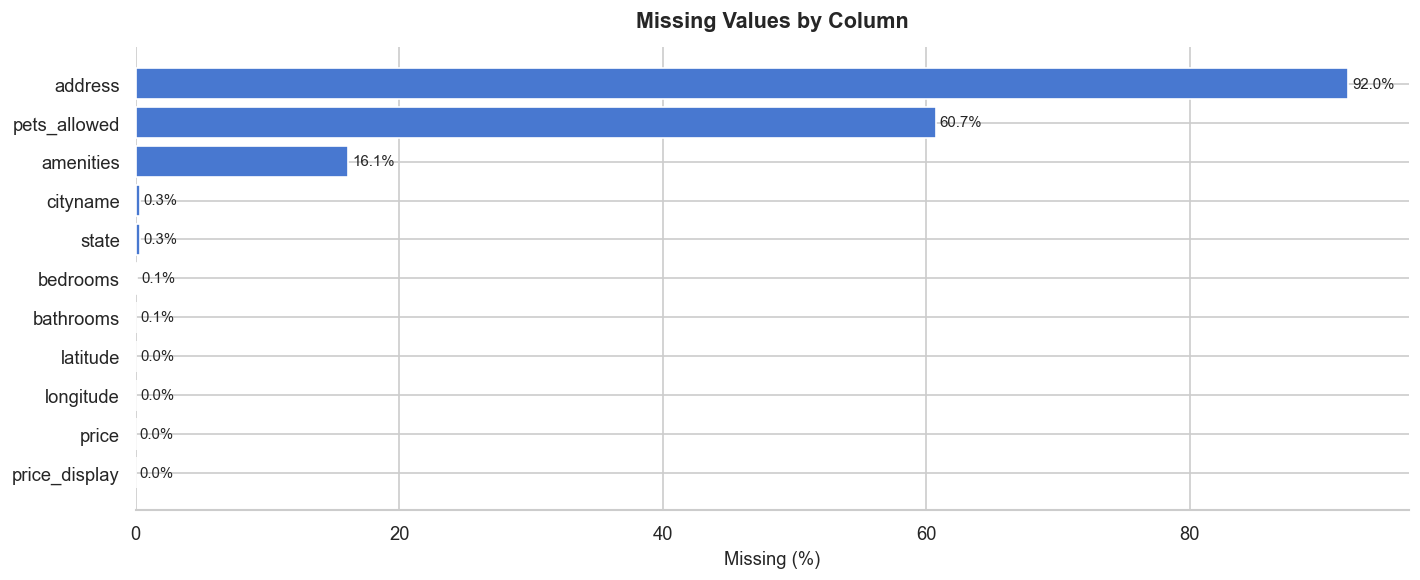

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(missing.index, missing_pct.values, color=sns.color_palette('muted')[0])
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column', fontweight='bold', pad=12)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.invert_yaxis()
sns.despine(left=True)
plt.tight_layout()
plt.show()

- The feature 'Address' has 92% missing values, but 'latitude' and 'longitude' make up for it. So it should not be much of an issue.

- Similarly the feature 'pets_allowed' has 60.7% missing values but we feel that is not a crucial category and would not cause much harm in not having a value.

- Amenities has 16.1% missing values, these rows will be treated as having no amenities.

In [6]:
df.drop(columns=['price_display'], inplace=True)
df.head(1)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.852,-118.3759,RentLingo,1577360355


- We decided to not drop any rows with null values since they might be useful in the future for fake listings prediction. But, 'price_display' and 'price' show the exact same information, but 'price' is numerical and is therefore easy to work with, so we will be dropping 'price_display'.

### Key Feature Distributions

We will explore the shape of core numerical features: rental price, size, number of bedrooms and bathrooms. This will help us  understand our distributions better before we start flagging anomalies.

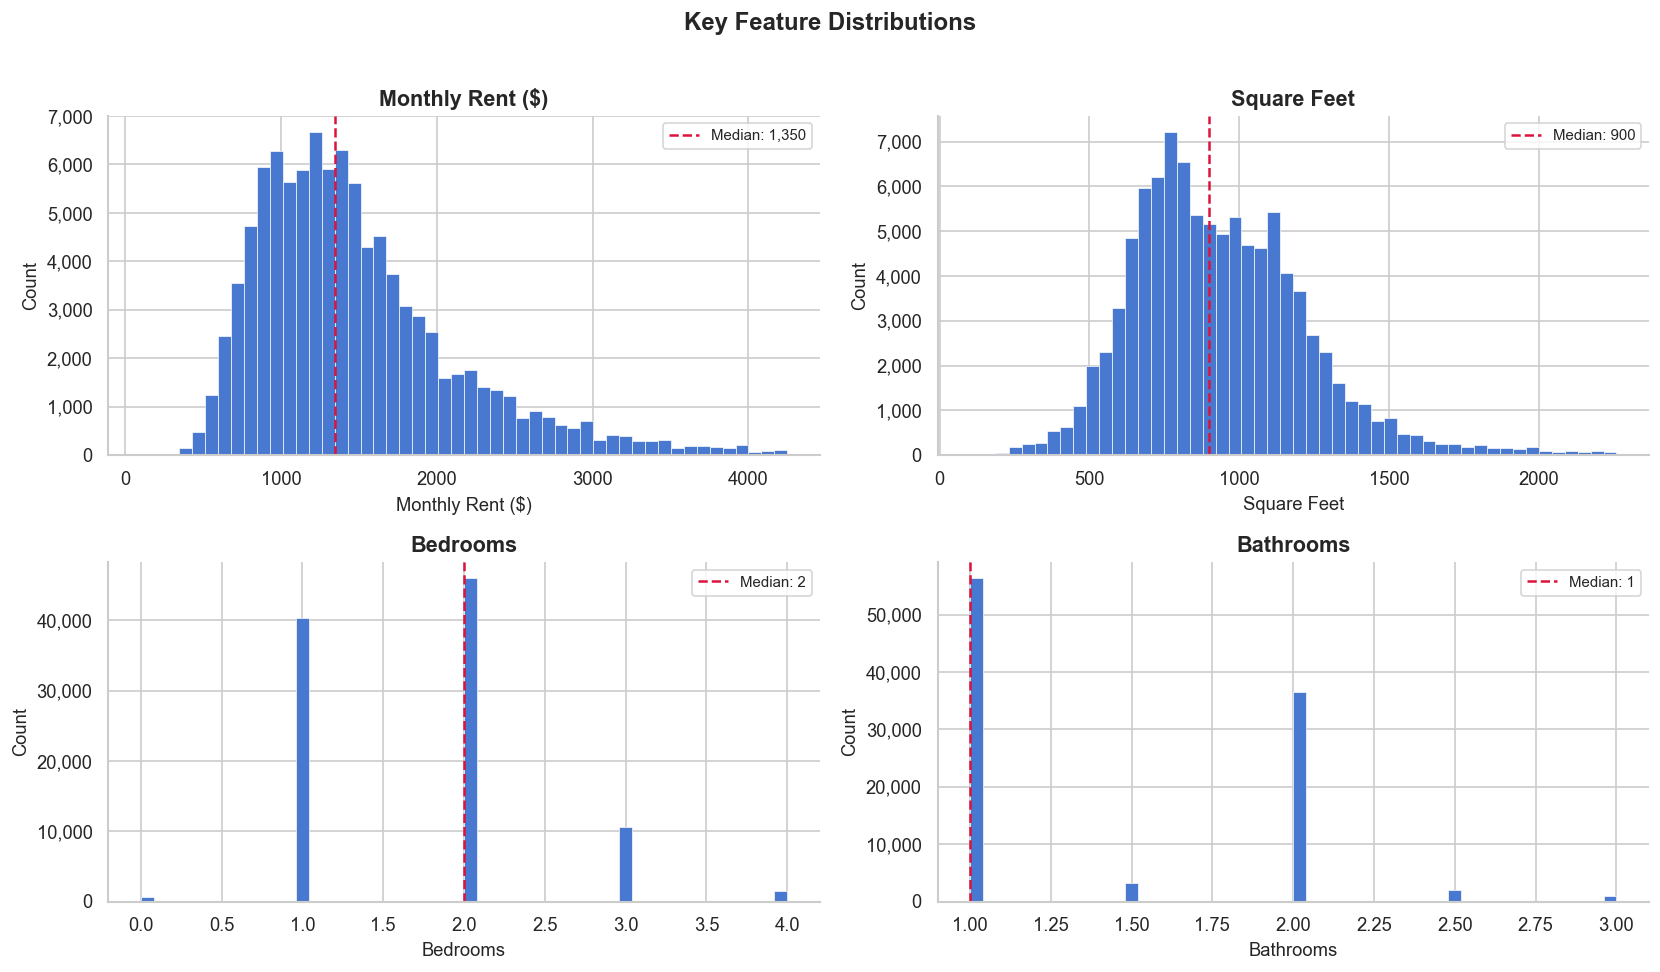

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Key Feature Distributions', fontweight='bold', y=1.01)

features = [
    ('price',       'Monthly Rent ($)'),
    ('square_feet', 'Square Feet'),
    ('bedrooms',    'Bedrooms'),
    ('bathrooms',   'Bathrooms'),
]

for ax, (col, label) in zip(axes.flat, features):
    data = df[col].dropna()
    upper = data.quantile(0.99) # Clip at 99th percentile to reduce outlier impact
    data_clipped = data[data <= upper]
    ax.hist(data_clipped, bins=50, color=sns.color_palette('muted')[0],
            edgecolor='white', linewidth=0.4)
    median_val = data.median()
    ax.axvline(median_val, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Median: {median_val:,.0f}')
    ax.set_title(label, fontweight='semibold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

#### Observations

- **Monthly Rent** is right-skewed (median \$1,350). The long right tail is likely due to luxury units in expensive cities.

- **Square Feet** follows a similar right-skewed shape (median 900 sqft). A listing that is both very cheap *and* large will result in a low price-per-sqft, which is a strong fake signal.

- **Bedrooms & Bathrooms** are discrete integer values with no fractional values. This confirms clean data. The typical listing is 2 bed / 1 bath.

### What are the categories?

In [8]:
# show different categories of the dataset
print(df['category'].value_counts())

category
housing/rent/apartment            99431
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64


### Observations
We have a few different categories lets see how different they are

In [9]:
df_rentapt = df[df['category'] == 'housing/rent/apartment']
df_rentapt.head(5)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


This is our biggest subset of categories.

In [10]:
# print category housing/rent/home
df_renthome = df[df['category'] == 'housing/rent/home']
df_renthome

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
6394,5663111837,housing/rent/home,"622 North Wayne Street, Apartment. A",Milledgeville STUCCO SIDING - DOWNTOWN WAYNE S...,"AC,Cable or Satellite,Dishwasher,Internet Acce...",1.0,2.0,USD,No,Thumbnail,NaN,625.0,Monthly,828,622 North Wayne St,Milledgeville,GA,33.0769,-83.3032,ListedBuy,1576878211
6395,5663106093,housing/rent/home,"1350 Irwinton Road, Apartment. B",Milledgeville SWINT AVENUE/441 SOUTH  VINYL S...,"AC,Cable or Satellite,Internet Access,Patio/De...",1.0,1.0,USD,No,Thumbnail,NaN,475.0,Monthly,664,1350 Irwinton Rd,Milledgeville,GA,33.0769,-83.3032,ListedBuy,1576877678
50971,5411277752,housing/rent/home,"529 S 10th St Apartment 2 San Jose, CA 95112",San Jose three Beds/two Baths Apartment in Dow...,"AC,Cable or Satellite,Dishwasher,Fireplace,Gar...",2.0,3.0,USD,No,Thumbnail,"Cats,Dogs",2000.0,Monthly,942,NaN,San Jose,CA,37.3108,-121.8645,ListedBuy,1562423091
50986,5411274086,housing/rent/home,Renovated Two BR Duplex Home for Rent on James...,"Move into this gorgeous, completely up-to-date...",Washer Dryer,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1450.0,Monthly,950,NaN,Charleston,SC,32.8113,-79.9947,ListedBuy,1562422872


This looks very similar to the apartments subset.

In [11]:
df_rent = df[df['category'] == 'housing/rent']
df_rent

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
11930,5508873595,housing/rent,Newport News - Well maintained Two BR home wit...,Enclosed backyard and more. Centrally Located ...,Parking,1.5,2.0,USD,No,Yes,NaN,1250.0,Monthly,1137,NaN,Newport News,VA,37.1451,-76.5397,RentDigs.com,1568758737
57230,5197883238,housing/rent,Lovely 5 BR and a Loft home in desirable Cresl...,"1 beds and full size bathroom, downstairs. Lar...","Fireplace,Parking,Patio/Deck,Wood Floors",3.0,5.0,USD,No,Thumbnail,NaN,2695.0,Monthly,2914,NaN,Elk Grove,CA,38.4070,-121.3752,RentDigs.com,1550826861
62646,5198222557,housing/rent,Beautiful Three BR Two BA home with a bonus lo...,"Park, shopping, restaurants, interstate access...","Patio/Deck,Washer Dryer",2.0,3.0,USD,No,Yes,NaN,1300.0,Monthly,1580,NaN,Lexington,KY,38.0983,-84.4932,RentDigs.com,1550841933
68844,5198404371,housing/rent,Contemporary ranch style home with Three BR & ...,Large sunroom & wrap around deck over looking ...,"Fireplace,Patio/Deck,Wood Floors",2.0,3.0,USD,No,Thumbnail,NaN,1595.0,Monthly,2043,NaN,Newport News,VA,36.8961,-76.2550,RentDigs.com,1550849465
75995,5197797656,housing/rent,"Excellent home with 2 bdrooms, loft, and 1 BA....","Every room has a ceiling fan in it, along with...","Alarm,Fireplace,Refrigerator",1.0,3.0,USD,No,Yes,"Cats,Dogs",800.0,Monthly,2500,NaN,Kansas City,MO,39.0342,-94.5429,RentDigs.com,1550821168
91265,5122165581,housing/rent,"Pittsburg Three BR plus loft, 2. Five BA Home - .",This home is walkable distance to Bart station...,NaN,2.5,3.0,USD,No,Yes,NaN,2695.0,Monthly,2026,NaN,Pittsburg,CA,38.0159,-121.9111,RentDigs.com,1544263338
92570,5121297015,housing/rent,Welcome home to the most desired loft style li...,"This beautiful home has oversized windows, ele...","AC,Dishwasher,Gym,Patio/Deck,Refrigerator,Wash...",1.0,1.0,USD,No,Yes,"Cats,Dogs",3700.0,Monthly,700,NaN,Brooklyn,NY,40.6496,-73.9596,RentDigs.com,1544191798


Again it looks very similar to the two previous categories.

In [12]:
df_comercial = df[df['category'] == 'housing/rent/commercial/retail']
##df_comercial.head(5)
df_comercial.tail(5)
# print full body of the first 5 rows of the dataset

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
51329,5508732207,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,"Square footage: 1237 square feet, unit number:...","Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1960.0,Monthly,1237,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748329
51330,5508728040,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,An upscale community of beautiful Brickyard Ap...,"Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1935.0,Monthly,1183,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748020
51331,5508733274,housing/rent/commercial/retail,One BR Apartment - In the heart of a bustling ...,"Square footage: 877 sq. feet, unit number: 306...","Gym,Parking,Pool,Wood Floors",1.0,1.0,USD,No,Yes,NaN,1655.0,Monthly,877,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748411
51332,5508732431,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,"Square footage: 1183 sq. feet, unit number: 21...","Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1935.0,Monthly,1183,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748346
51333,5508731090,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,"Square footage: 1237 square ft, unit number: 1...","Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1945.0,Monthly,1237,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748241


All these rows seems to have same coordinates they might an apartment complex.

In [13]:
print(df_comercial['latitude'].value_counts())
print(df_comercial['longitude'].value_counts())

latitude
39.0430    41
39.7136     1
Name: count, dtype: int64
longitude
-76.9077     41
-105.0655     1
Name: count, dtype: int64


Apparently one row is different lets explore!

In [14]:
# find the row with latitude 39.7136
weird_apt = df_comercial[(df_comercial['latitude'] == 39.7136) & (df_comercial['longitude'] == -105.0655)]
weird_apt

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
51306,5508751406,housing/rent/commercial/retail,Two BR Apartment - Walk out your front door to...,Even fun nightlife like Lucky Strike Lanes and...,Parking,2.0,2.0,USD,No,Thumbnail,"Cats,Dogs",2165.0,Monthly,804,NaN,Denver,CO,39.7136,-105.0655,RentDigs.com,1568749831


In [15]:
print(weird_apt['title'].values[0])
print(weird_apt['body'].values[0])

Two BR Apartment - Walk out your front door to a menu of on-site retail and
Even fun nightlife like Lucky Strike Lanes and Century Theaters. Just around the corner you'll find popular shopping centers such as Target and Whole Foods. And with a location just ten miles from Downtown, commuting to surrounding employers is a cinch. Best of all residents will have easy access to the West Corridor Light Rail. Leasing Info. Income Requirement: Must have 2. 5x the rent in total household income before taxes, include income from all adults. Pet conditions. Ok for pets: Dogs, Cats. Pet restrictions: Weight limit: 80 pounds combined. Pet limit: two pets max. Pet fee: $300 1st pet, $150 additional pet. Pet deposit: $300 1st pet, $150 additional pet. Pet rent: $25/month per pet. Parking. Parking Information: Other, unassigned. Garage parking and off onstreet parking on our parking policies.


- This looks like a normal apartment listing and shouldn't be removed from our final set. 

- Now lets look at the 41 other listings that have the same coordinates as each other.

In [16]:
for i, text in enumerate(df_comercial['body'].head(5), 1):
    print(f"\n--- Row {i} ---\n{text}\n")


--- Row 1 ---
Square footage: 1113 square feet, unit number: 3085. An upscale community of beautiful Brickyard Apartments. Our apartment homes feature sophisticated amenities and premium finishes and fixtures and are enveloped by plenty of excellent community additions. Our in-home available amenities premium granite counters, hickory hardwood flooring, faux wood blinds, and full-size washers and dryers. You will find overhead fans and private balconies, customized cabinets, stainless appliances, and more. Our community boasts an extravagant club room with a gourmet serving kitchen, grilling areas, a theater, electric car charging station, garage parking, a fitness facilities, swimming pool, and dozens of additional features. Discover all that our Brickyard Apartments have to offer,.


--- Row 2 ---
Square footage: 615 sq-ft, unit number: 4056. An upscale community of beautiful Brickyard Apartments. Our apartment homes feature sophisticated amenities and premium finishes and fixtures 

In [17]:
for i, text in enumerate(df_comercial['title'].head(5), 1):
    print(f"\n--- Row {i} ---\n{text}\n")


--- Row 1 ---
Two BR Apartment - In the heart of a bustling retail environment is The.


--- Row 2 ---
One BR Apartment - In the heart of a bustling retail environment is The.


--- Row 3 ---
One BR Apartment - In the heart of a bustling retail environment is The.


--- Row 4 ---
Two BR Apartment - In the heart of a bustling retail environment is The.


--- Row 5 ---
One BR Apartment - In the heart of a bustling retail environment is The.



- These apartments seem to be from one apartment complex given that the unit number, sq feet etc changes but the overall body remains the same. 

- After looking up the coordinates on google maps we think this data is not fake and can be used.

In [18]:
df_rentapt = df[df['category'].isin(['housing/rent/short_term', 'housing/rent/condo', 'housing/rent/other'])]
df_rentapt

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
7056,5641785233,housing/rent/short_term,Apartment sublease $775/mo,Sublease needed from December/beginning of Jan...,"Parking,Pool",NaN,2.0,USD,No,Thumbnail,"Cats,Dogs",775.0,Monthly,850,NaN,Boulder,CO,40.0213,-105.2552,ListedBuy,1575602264
7119,5629355898,housing/rent/short_term,Room with private bathroom for rent in a furni...,I have a vacant room furnished with a queen be...,"Gym,Internet Access,Pool,Washer Dryer",2.0,2.0,USD,No,Thumbnail,NaN,500.0,Monthly,900,NaN,Bryan,TX,30.7084,-96.3470,ListedBuy,1575062563
50406,5470745113,housing/rent/short_term,Short Term Lease Take-Over in Gorgeous Apartment,Amazing Lease Take-Over Opportunity  Spread t...,NaN,1.5,1.0,USD,No,Thumbnail,NaN,1489.0,Monthly,838,NaN,Columbia,MD,39.2040,-76.8558,ListedBuy,1566336313
50630,5439044208,housing/rent/condo,3 BR Townhouse - Apartments in Westbury.,"NY is a beautiful to be all year round, with a...","AC,Clubhouse,Gym,Parking,Pool",2.0,3.0,USD,No,Thumbnail,NaN,3380.0,Monthly,1015,NaN,Westbury,NY,40.7567,-73.5776,ListedBuy,1564355563
50679,5434474859,housing/rent/condo,"8 Towne Park Ct., Apartment 8, Little Rock, AR...",Real Property Management. Call 501-222-X today...,"AC,Fireplace,Patio/Deck",2.0,2.0,USD,No,Thumbnail,NaN,650.0,Monthly,1061,8 Towne Park Court,Little Rock,AR,34.7264,-92.3480,ListedBuy,1564017186
50967,5411278120,housing/rent/other,Upper level duplex in St. Paul - immediate ope...,Available now!! Fully renovated Victorian dupl...,"AC,Parking,Washer Dryer",1.0,3.0,USD,No,Thumbnail,NaN,1275.0,Monthly,1100,NaN,Saint Paul,MN,44.9405,-93.1027,ListedBuy,1562423101
51029,5402391239,housing/rent/condo,Cristalla Condominiums - Studio,AVAILABLE SEPT 1: The Cristalla is situated on...,"Dishwasher,Elevator,Fireplace,Garbage Disposal...",1.0,0.0,USD,No,Thumbnail,NaN,1925.0,Monthly,436,NaN,Seattle,WA,47.6160,-122.3275,ListedBuy,1561823368
51653,5315569841,housing/rent/short_term,FREE RENT] Luxury Apartment for Sublease One B...,We are now offering free rent for the months o...,Washer Dryer,1.0,1.0,USD,No,Thumbnail,NaN,1078.0,Monthly,783,NaN,Round Rock,TX,30.5114,-97.6704,Claz,1556960900


### Overall Observation
After complete analysis of all different categories it seems like there is not much difference between categories therefore we can include all categories and the category column does not add much value.


### Geographic Distribution

Plotting listing locations across the continental US gives us a sense of geographic coverage and density which is important context for the Zillow neighborhood pricing integration that we will be adding.

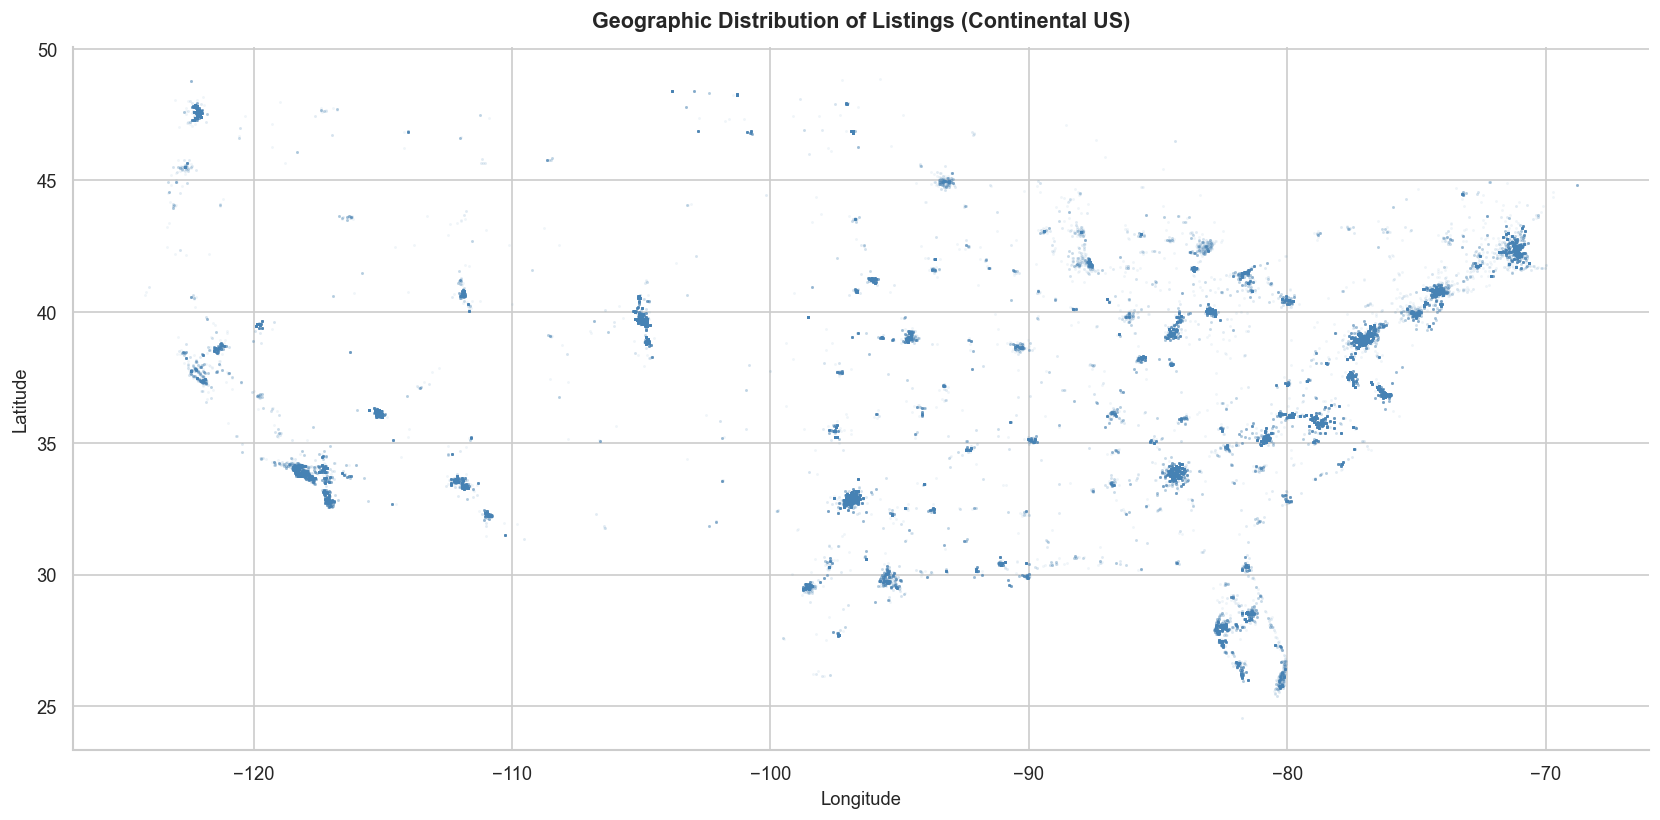

Listings plotted: 99,378 / 99,492 total


In [19]:
df_geo = df[
    df['latitude'].between(24, 50) & df['longitude'].between(-125, -65)
].dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(
    df_geo['longitude'], df_geo['latitude'],
    alpha=0.08, s=3, color='steelblue', linewidths=0
)
ax.set_title('Geographic Distribution of Listings (Continental US)',
             fontweight='bold', pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
sns.despine()
plt.tight_layout()
plt.show()

print(f'Listings plotted: {len(df_geo):,} / {len(df):,} total')

Listings are heavily concentrated in major coastal and southern metros such as the Bay Area, Los Angeles, Houston, Atlanta and New York City. This geographic skew is important context since price norms vary significantly by region.

In [20]:
# Rows excluded from the geographic plot
outside = df[
    ~(df['latitude'].between(24, 50) & df['longitude'].between(-125, -65))
].dropna(subset=['latitude', 'longitude'])

print(f"Plotted:  {len(df_geo):,}")
print(f"Excluded: {len(outside):,}")
print()
print(outside[['state', 'cityname', 'latitude', 'longitude']].head(20).to_string())

Plotted:  99,378
Excluded: 89

     state     cityname  latitude  longitude
152     HI       Kailua   21.3991  -157.7452
327     AK    Anchorage   61.1723  -149.8414
328     AK    Anchorage   61.1723  -149.8414
329     AK    Anchorage   61.1723  -149.8414
447     HI     Honolulu   21.3155  -157.8379
706     HI      Kaneohe   21.4199  -157.8117
881     AK  Eagle River   61.3186  -149.5355
882     AK    Anchorage   61.1723  -149.8414
925     HI     Honolulu   21.3155  -157.8379
1004    AK    Anchorage   61.1521  -149.8508
1028    AK    Anchorage   61.1723  -149.8414
1029    AK    Anchorage   61.1723  -149.8414
1054    HI       Kailua   21.3991  -157.7452
1273    AK    Anchorage   61.1723  -149.8414
1492    HI     Mililani   21.4476  -158.0221
1564    AK    Anchorage   61.1723  -149.8414
1602    AK      Wasilla   61.5940  -149.4124
1685    AK    Anchorage   61.1723  -149.8414
1713    AK    Anchorage   61.1723  -149.8414
1797    HI     Honolulu   21.3155  -157.8379


- As expected, the geographic distribution does not include listings from Alaska and Hawaii but it is included in the model training.

In [21]:
# Flag bad coordinates: (0, 0), out-of-range values, or missing
bad_coords = (
    df['latitude'].isna() |
    df['longitude'].isna() |
    (df['latitude'] == 0) |
    (df['longitude'] == 0) 
)

print(f"Rows with bad coordinates: {bad_coords.sum()}")
print()
print(df[bad_coords][['latitude', 'longitude', 'state', 'cityname']].head(20).to_string())

# Drop them
df = df[~bad_coords].reset_index(drop=True)
print(f"\nDataset size after removing bad coordinates: {len(df):,}")

Rows with bad coordinates: 25

       latitude  longitude state cityname
5584        NaN        NaN   NaN      NaN
5585        NaN        NaN   NaN      NaN
5639        NaN        NaN   NaN      NaN
5899        NaN        NaN   NaN      NaN
6385        NaN        NaN   NaN      NaN
6392        NaN        NaN   NaN      NaN
6393        NaN        NaN   NaN      NaN
6525        NaN        NaN   NaN      NaN
6601        NaN        NaN   NaN      NaN
6740        NaN        NaN   NaN      NaN
51099       NaN        NaN   NaN      NaN
51109       NaN        NaN   NaN      NaN
51267       NaN        NaN   NaN      NaN
51724       NaN        NaN   NaN      NaN
79878       NaN        NaN   NaN      NaN
79879       NaN        NaN   NaN      NaN
79894       NaN        NaN   NaN      NaN
79897       NaN        NaN   NaN      NaN
79905       NaN        NaN   NaN      NaN
79906       NaN        NaN   NaN      NaN

Dataset size after removing bad coordinates: 99,467


- Bad Coordinates: Values that have null Latitude and Longitude values. We have 25 'Bad Coordinates' that we removed. 

## Feature Engineering

We are still working on the feature engineering part and haven't added the Zillow feature either.

### 1. Price Per Sqft

- This feature is added to calculate price per square feet.
- This would help us compare houses of different sizes and compare it to the average price of a house of similar size.

In [22]:
# Make sure numeric columns are truly numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["square_feet"] = pd.to_numeric(df["square_feet"], errors="coerce")

# Avoid divide-by-zero and invalid sqft values
valid_sqft = df["square_feet"] > 0
df["price_per_sqft"] = np.where(valid_sqft, df["price"] / df["square_feet"], np.nan)

# Quick check
df[["price", "square_feet", "price_per_sqft"]].head()

,price,square_feet,price_per_sqft
0,2195.0,542,4.049815
1,1250.0,1500,0.833333
2,1395.0,1650,0.845455
3,1600.0,820,1.951220
4,975.0,624,1.562500


In [23]:
df["price_per_sqft"].describe()

count    99466.000000
mean         1.685871
std          0.858484
min          0.047083
25%          1.120221
50%          1.470303
75%          2.001378
max         37.023977
Name: price_per_sqft, dtype: float64

In [24]:
df["price_per_sqft"].isna().sum()

np.int64(1)

In [25]:
df.nlargest(10, "price_per_sqft")[["price", "square_feet", "price_per_sqft", "cityname", "state"]]

,price,square_feet,price_per_sqft,cityname,state
6853,52500.0,1418,37.023977,Barstow,CA
7138,2475.0,130,19.038462,Manhattan,NY
17121,35000.0,2269,15.425297,West Hollywood,CA
36969,12995.0,865,15.023121,Los Angeles,CA
45807,33165.0,2211,15.000000,Pacific Palisades,CA
45294,8700.0,607,14.332784,West Hollywood,CA
1109,1800.0,132,13.636364,Venice,CA
88039,13278.0,988,13.439271,New York,NY
4998,1390.0,107,12.990654,Arlington,VA
96810,6100.0,500,12.200000,New York,NY


In [26]:
# Per-city IQR on price/sqft. Skip cities with too few listings —
# IQR is meaningless when n < 20 and produces spurious "anomaly" flags.
df["is_price_anomaly"] = False

city_counts = df['cityname'].value_counts()
MIN_CITY_LISTINGS = 20
ok_cities = set(city_counts[city_counts >= MIN_CITY_LISTINGS].index)

skipped_cities = len(city_counts) - len(ok_cities)
skipped_rows = df['cityname'].map(city_counts).lt(MIN_CITY_LISTINGS).sum()
print(f"Skipped {skipped_cities:,} cities with < {MIN_CITY_LISTINGS} listings "
      f"({skipped_rows:,} rows; IQR not meaningful)")

for city in ok_cities:
    city_data = df[df['cityname'] == city]
    Q1_city = city_data["price_per_sqft"].quantile(0.25)
    Q3_city = city_data["price_per_sqft"].quantile(0.75)
    IQR_city = Q3_city - Q1_city

    bounds = (Q1_city - 1.5 * IQR_city, Q3_city + 1.5 * IQR_city)
    df.loc[df['cityname'] == city, "is_price_anomaly"] = (
        (df[df['cityname'] == city]["price_per_sqft"] < bounds[0]) |
        (df[df['cityname'] == city]["price_per_sqft"] > bounds[1])
    )

print(f"Total is_price_anomaly = True: {df['is_price_anomaly'].sum():,} "
      f"({df['is_price_anomaly'].mean():.2%})")


Skipped 2,229 cities with < 20 listings (9,551 rows; IQR not meaningful)
Total is_price_anomaly = True: 2,929 (2.94%)


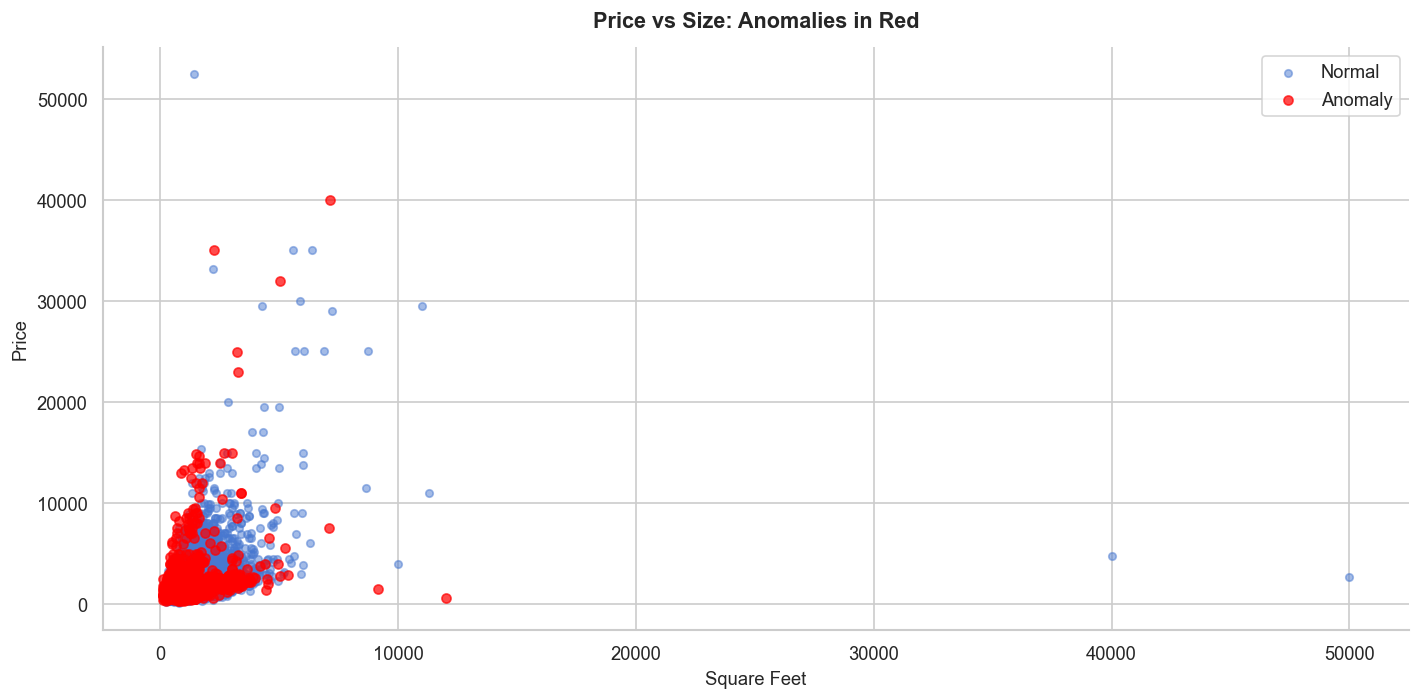

In [27]:
# Price vs Square Feet — anomalies highlighted
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df[~df['is_price_anomaly']]['square_feet'],
           df[~df['is_price_anomaly']]['price'],
           alpha=0.5, label='Normal', s=20)
ax.scatter(df[df['is_price_anomaly']]['square_feet'],
           df[df['is_price_anomaly']]['price'],
           alpha=0.7, color='red', label='Anomaly', s=30)
ax.set_xlabel('Square Feet')
ax.set_ylabel('Price')
ax.set_title('Price vs Size: Anomalies in Red', fontweight='bold', pad=12)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [28]:
# 1. Count total anomalies
print(f"Total anomalies detected: {df['is_price_anomaly'].sum()}")
print(f"Percentage of dataset: {df['is_price_anomaly'].sum() / len(df) * 100:.2f}%")

Total anomalies detected: 2929
Percentage of dataset: 2.94%


In [29]:
# 3. View actual anomalous listings
df[df["is_price_anomaly"]][["cityname", "price", "square_feet", "price_per_sqft", "title"]].head(20)

,cityname,price,square_feet,price_per_sqft,title
31,Austin,1722.0,453,3.801325,Studio apartment 300 E Riverside Dr
52,Tulsa,495.0,360,1.375000,One BR 2613 E Archer St.
55,Providence,2095.0,390,5.371795,Studio apartment 1 Point St
82,Omaha,885.0,468,1.891026,Studio apartment 3618 Farnam St
85,Carlsbad,1795.0,500,3.590000,One BR 350-370 Chinquapin Avenue
99,Austin,1729.0,448,3.859375,Studio apartment 311 Bowie
117,Gainesville,1160.0,338,3.431953,Studio apartment 1258 Nw 3rd Ave
118,College Station,1225.0,450,2.722222,One BR 717 University Dr
128,Greeley,1025.0,500,2.050000,Studio apartment 2101 22nd Avenue
139,New Bedford,1495.0,825,1.812121,One BR 42 West Hill Road


### 2. Over-Accommodation Metric

- Scam listings tend to have a high amenity count to attract a renter. 
- That is why we decided to build this feature which would help us capture this. 

In [30]:
# 1. Count amenities
df["amenity_count"] = df["amenities"].fillna("").str.split(",").apply(len)
# Remove rows where amenities was empty (they'd have count 1 for empty string)
df.loc[df["amenities"].fillna("") == "", "amenity_count"] = 0

# Quick check
print(df["amenity_count"].describe())
print(df[df["amenity_count"] > 0][["amenities", "amenity_count"]].head())

count    99467.000000
mean         3.663587
std          3.302832
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         18.000000
Name: amenity_count, dtype: float64
                                         amenities  amenity_count
21  Fireplace,Gym,Parking,Pool,Storage,Wood Floors              6
22                                      Gated,Pool              2
23                         Dishwasher,Parking,Pool              3
24                         Dishwasher,Parking,Pool              3
25                                        Gym,Pool              2


In [31]:
# 2. Pets Allowed Count
df["pets_allowed_count"] = df["pets_allowed"].fillna("").str.split(",").apply(len)
df.loc[df["pets_allowed"].fillna("") == "", "pets_allowed_count"] = 0

# Quick check
print(df["pets_allowed_count"].describe())
print(df[df["pets_allowed_count"] > 0][["pets_allowed", "pets_allowed_count"]].head())

count    99467.000000
mean         0.765570
std          0.961923
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max          3.000000
Name: pets_allowed_count, dtype: float64
  pets_allowed  pets_allowed_count
0         Cats                   1
1    Cats,Dogs                   2
3    Cats,Dogs                   2
4    Cats,Dogs                   2
5    Cats,Dogs                   2


## 3. Zillow ZORI Integration

We pair each listing with a Zillow Observed Rent Index (ZORI) baseline so we can measure how far a listed price deviates from the local market. ZORI is sparse by design because Zillow only publishes a value when it has enough listings to confidently calculate an average price. We therefore built a two-tier fallback: a direct ZIP-level match first, and then a spatial k-NN model for listings in ZIPs without data. 

In [32]:
ZORI_ZIP_PATH = 'Zip_zori_uc_sfrcondomfr_sm_month.csv'

zori_zip  = pd.read_csv(ZORI_ZIP_PATH, dtype=str)
date_cols_z = [c for c in zori_zip.columns if c.startswith('20')]
cols_2019   = [c for c in date_cols_z if c.startswith('2019')]

zori_num = zori_zip[date_cols_z].apply(pd.to_numeric, errors='coerce')
miss_per_zip = zori_num.isna().mean(axis=1)

print(f"Shape: {zori_zip.shape[0]:,} ZIPs x {len(date_cols_z)} monthly columns")
print(f"Date range: {date_cols_z[0]}  ->  {date_cols_z[-1]}")

print("\nMissingness per ZIP (fraction of months with no Zillow value):")
print(miss_per_zip.describe().round(3).to_string())

has_2019 = zori_num[cols_2019].notna().any(axis=1)
print(f"\nZIPs with >= 1 non-null cell in 2019: "
      f"{has_2019.sum():,} / {len(zori_zip):,}  ({has_2019.mean():.1%})")

print("\nTop 15 states by ZIP count in ZORI:")
print(zori_zip['State'].value_counts().head(15).to_string())


Shape: 8,188 ZIPs x 135 monthly columns
Date range: 2015-01-31  ->  2026-03-31

Missingness per ZIP (fraction of months with no Zillow value):
count    8188.000
mean        0.612
std         0.337
min         0.000
25%         0.348
50%         0.674
75%         0.926
max         0.993

ZIPs with >= 1 non-null cell in 2019: 2,265 / 8,188  (27.7%)

Top 15 states by ZIP count in ZORI:
State
CA    958
TX    732
FL    685
NY    394
PA    326
OH    274
IL    256
GA    253
NC    252
NJ    248
WA    223
VA    220
MI    212
MA    200
AZ    194


We see that ZORI is intentionally sparse, about 73% of ZIP-month cells are empty because low-volume markets don't clear Zillow's confidence threshold. Only about 28% of ZIPs have any 2019 data, which is the main posting year for our listings. That's not as bad as it sounds: the ZIPs with data tend to be the denser urban markets where most listings are concentrated. For everything else we fall back to spatial k-NN.

In [33]:
zori_zip.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,2015-06-30,2015-07-31,2015-08-31,2015-09-30,2015-10-31,2015-11-30,2015-12-31,2016-01-31,2016-02-29,2016-03-31,2016-04-30,2016-05-31,2016-06-30,2016-07-31,2016-08-31,2016-09-30,2016-10-31,2016-11-30,2016-12-31,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,2018-06-30,2018-07-31,2018-08-31,2018-09-30,2018-10-31,2018-11-30,2018-12-31,2019-01-31,2019-02-28,2019-03-31,2019-04-30,2019-05-31,2019-06-30,2019-07-31,2019-08-31,2019-09-30,2019-10-31,2019-11-30,2019-12-31,2020-01-31,2020-02-29,2020-03-31,2020-04-30,2020-05-31,2020-06-30,2020-07-31,2020-08-31,2020-09-30,2020-10-31,2020-11-30,2020-12-31,2021-01-31,2021-02-28,2021-03-31,2021-04-30,2021-05-31,2021-06-30,2021-07-31,2021-08-31,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30,2022-10-31,2022-11-30,2022-12-31,2023-01-31,2023-02-28,2023-03-31,2023-04-30,2023-05-31,2023-06-30,2023-07-31,2023-08-31,2023-09-30,2023-10-31,2023-11-30,2023-12-31,2024-01-31,2024-02-29,2024-03-31,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,1396.4206111286828,1399.5473267210318,1406.2677043319768,1412.3621320359555,1417.1815898131797,1418.9656740680748,1424.4689443265354,1421.8571992460272,1415.8454989171046,1408.1787094212204,1401.2381773292182,1384.3909165950831,1376.8066368240573,1364.927658880972,1373.5966065797854,1363.5905703717435,1363.8683834283324,1360.4424252982217,1360.8038895351915,1358.8115070117044,1348.6479033378973,1340.2589657186704,1326.5659883320643,1316.7064612195163,1316.7067905751574,1330.9468241021157,1343.7290823794133,1348.598983019856,1354.5883730287676,1361.2325241810101,1361.9526016724826,1351.819037793669,1359.039085975612,1373.4758541059934,1386.95574811628,1388.4949694422808,1396.1880771256322,1403.2709614031867,1407.835757823313,1403.3853278282047,1400.7339295111592,1397.1218716139051,1391.1639195022562,1381.6116137805739,1370.5717785865106,1368.144934147876,1372.4285195601794,1378.2852658662264,1384.4644552314867,1392.731597584074,1401.1635245157695,1405.0604371764728,1403.8028161272457,1400.4803512376757,1401.21920890898,1405.0676468759762,1401.3508424093145,1400.598848515844,1395.73681599394,1401.2245363333236,1403.1917768915332,1409.1878161926413,1413.9565679265195,1423.4810800117566,1417.7425670219168,1416.2217917143485,1407.7380390660749,1417.2334975734657,1427.0310603111238,1425.7226769385577,1435.0267582291272,1436.6248711144538,1454.88038594945,1457.559404612522,1466.7190423826544,1482.230082081463,1510.752644649438,1548.474620151232,1582.419554207488,1607.67046441449,1621.1111132447081,1633.569292485795,1647.2991123122215,1653.3122951481025,1656.1016440960411,1657.8730371474915,1666.1701610192147,1687.786139109287,1710.2181939825791,1736.3534616812585,1749.3065024838413,1750.5781755531302,1748.7452746312997,1739.639877430487,1722.9179269997433,1713.2087973538394,1724.0990183613005,1732.722445227451,1745.4345596252972,1734.9797754726005,1747.360528022266,1754.6634357619284,1762.0095053830512,1766.1924466460823,1764.1672401681344,1760.9612610291008,1746.8426162613364,1736.3869584310635,1727.4136803149897,1736.8887381643249,1742.880437408535,1758.2112570457557,1760.307936937413,1769.7663381905177,1773.5139108189892,1777.4607268407058,1766.9053260269889,1756.2884436409,1749.9802190202122,1741.7529376259,1739.0013956669154,1736.8842575933631,1745.240655523929,1748.1066089022202,1752.4107843145243,1752.349868

In [34]:
from sklearn.neighbors import BallTree
import pgeocode

# pgeocode caches the GeoNames database locally after the first download
nomi   = pgeocode.Nominatim('us')
zip_db = (
    nomi._data[['postal_code', 'place_name', 'state_code', 'latitude', 'longitude']]
    .dropna()
    .reset_index(drop=True)
)
zip_db['postal_code'] = zip_db['postal_code'].str.zfill(5)

# BallTree with haversine metric — coordinates in radians
zip_coords_rad = np.radians(zip_db[['latitude', 'longitude']].values)
tree = BallTree(zip_coords_rad, metric='haversine')
print(f"BallTree built from {len(zip_db):,} US ZIP centroids.")

# Batch query — single call for all ~99K listings
listing_coords_rad = np.radians(df[['latitude', 'longitude']].values)
_, idx = tree.query(listing_coords_rad, k=1)

matched = zip_db.iloc[idx.flatten()].reset_index(drop=True)
df['assigned_zip']       = matched['postal_code'].values
df['assigned_zip_state'] = matched['state_code'].values

# Spot-check: 10 random rows
print("\nRandom-sample validation (cityname | state | lat | lon | assigned_zip | zip_state):")
sample_cols = ['cityname', 'state', 'latitude', 'longitude', 'assigned_zip', 'assigned_zip_state']
print(df[sample_cols].sample(10, random_state=42).to_string(index=False))

# Flag state mismatches — expected near borders and for AK / HI listings
mismatch = df['state'].notna() & (df['state'] != df['assigned_zip_state'])
print(f"\nState mismatch (listing state != nearest ZIP state): "
      f"{mismatch.sum():,}  ({mismatch.mean():.1%})")
print("Most mismatches are border-city listings or AK/HI where the nearest")
print("continental ZIP is still assigned — downstream features will be noisy for those rows.")


BallTree built from 40,979 US ZIP centroids.

Random-sample validation (cityname | state | lat | lon | assigned_zip | zip_state):
     cityname state  latitude  longitude assigned_zip assigned_zip_state
        Edina    MN   44.9000   -93.3233        55410                 MN
    Vacaville    CA   38.3444  -121.9542        95687                 CA
   Burlington    KY   39.0242   -84.7451        41005                 KY
 Independence    KY   38.9400   -84.5518        41051                 KY
      Roswell    GA   34.0467   -84.3786        30075                 GA
   Somerville    MA   42.3895   -71.1039        02143                 MA
Winston Salem    NC   36.0457   -80.2648        27127                 NC
   Woodbridge    VA   38.6780   -77.3152        22192                 VA
      Hampton    VA   37.0435   -76.3397        23669                 VA
       Tucson    AZ   32.3126  -110.9189        85718                 AZ

State mismatch (listing state != nearest ZIP state): 464  (0.5%)
M

The BallTree assigns every listing a ZIP centroid. The 0.5% state mismatch rate is expected because border cities like Kansas City often snap to a ZIP just across the state line, and that's fine for a nearest-neighbor lookup. AK and HI listings get snapped to mainland ZIPs by the tree as well, but we handle those separately: the next cell adds an `in_continental_us` flag and those rows are explicitly zeroed out of ZORI matching regardless of what the BallTree found.

In [35]:
from pandas.tseries.offsets import MonthEnd

# Convert Unix epoch -> datetime, then snap to end-of-month to match ZORI column names
df['listing_dt'] = pd.to_datetime(df['time'], unit='s')
df['zori_month'] = (df['listing_dt'] + MonthEnd(0)).dt.strftime('%Y-%m-%d')

print("Listing year-month distribution (sorted):")
ym_counts = df['zori_month'].value_counts().sort_index()
print(ym_counts.to_string())

in_zori = set(ym_counts.index).issubset(set(date_cols_z))
print(f"\nUnique months in dataset: {ym_counts.index.nunique()}")
print(f"All listing months present in ZORI columns: {in_zori}")


Listing year-month distribution (sorted):
zori_month
2018-12-31    16055
2019-01-31      129
2019-02-28    31318
2019-03-31      133
2019-04-30      115
2019-05-31      121
2019-06-30      170
2019-07-31      470
2019-08-31      307
2019-09-30    43207
2019-10-31       65
2019-11-30       50
2019-12-31     7327

Unique months in dataset: 13
All listing months present in ZORI columns: True


#### Observation

- The data clusters sharply around three months: December 2018 (~16K listings), February 2019 (~31K listings) and September 2019 (~43K listings) together account for the vast majority. The remaining months are under 500 listings each.

In [36]:
# Clean up columns from any previous run of this cell
df.drop(columns=['in_continental_us', 'listing_county_key'], errors='ignore', inplace=True)

# Continental US bounding box (excludes AK, HI, PR)
df['in_continental_us'] = (
    df['latitude'].between(24, 50) & df['longitude'].between(-125, -65)
)
n_cont = df['in_continental_us'].sum()
print(f"Continental US listings : {n_cont:,}  ({n_cont / len(df):.1%})")
print(f"Excluded (AK/HI/PR/etc.): {len(df) - n_cont:,}")
print("Non-continental listings will always receive zori_granularity='none'.")

# Helper: normalize county names for cross-source comparison 
def _norm_county(c):
    """Strip, title-case, drop ' County' suffix so GeoNames and Zillow agree."""
    if pd.isna(c) or str(c).strip() == '':
        return ''
    c = str(c).strip().title()
    return c[:-7] if c.endswith(' County') else c

# pgeocode full table (includes county_name, already cached in memory)
pgeo_full = (
    nomi._data[['postal_code', 'county_name', 'state_code', 'latitude', 'longitude']]
    .dropna(subset=['latitude', 'longitude'])
    .assign(postal_code=lambda x: x['postal_code'].str.zfill(5))
    .reset_index(drop=True)
)

# ZORI centroid table: attach lat/lon + county to each ZORI ZIP
zori_zip_meta = (
    zori_zip[['RegionName', 'CountyName', 'State']]
    .assign(zori_zip=lambda x: x['RegionName'].str.zfill(5))
    .merge(
        pgeo_full[['postal_code', 'county_name', 'latitude', 'longitude']],
        left_on='zori_zip', right_on='postal_code', how='left',
    )
    .dropna(subset=['latitude', 'longitude'])
    .reset_index(drop=True)
)
zori_zip_meta['county_norm']   = zori_zip_meta['CountyName'].apply(_norm_county)
zori_zip_meta['pgeo_county_n'] = zori_zip_meta['county_name'].apply(_norm_county)

# Resolve county: prefer ZORI's CountyName, fall back to pgeocode county_name
county_res = np.where(
    zori_zip_meta['county_norm'] != '',
    zori_zip_meta['county_norm'],
    zori_zip_meta['pgeo_county_n'],
)

# 1-D object array of (county, state) tuples — np.array([[...]], dtype=object)
# would create a 2-D array, so we assign into a pre-allocated array explicitly.
states = zori_zip_meta['State'].values
zori_meta_county_key = np.empty(len(zori_zip_meta), dtype=object)
for _i in range(len(zori_zip_meta)):
    zori_meta_county_key[_i] = (county_res[_i], states[_i])

# BallTree on ZORI-ZIP centroids (separate from the listing-geocoding tree)
zori_coords_rad = np.radians(zori_zip_meta[['latitude', 'longitude']].values)
zori_tree       = BallTree(zori_coords_rad, metric='haversine')
zori_meta_zips  = zori_zip_meta['zori_zip'].values
print(f"\nZORI BallTree built from {len(zori_zip_meta):,} ZORI ZIPs with centroids.")

# County lookup for each listing's assigned_zip 
# pgeocode side
_pgeo_county = dict(zip(
    pgeo_full['postal_code'],
    list(zip(pgeo_full['county_name'].apply(_norm_county), pgeo_full['state_code'])),
))
# ZORI side (takes priority: ZORI county names are more authoritative for ZORI ZIPs)
_county_key_list = [(county_res[i], states[i]) for i in range(len(zori_zip_meta))]
_zori_county = dict(zip(zori_zip_meta['zori_zip'], _county_key_list))

_county_lookup = {**_pgeo_county, **_zori_county}
df['listing_county_key'] = df['assigned_zip'].map(_county_lookup)
resolved = df['listing_county_key'].notna().sum()
print(f"County resolved for {resolved:,} / {len(df):,} listings")


Continental US listings : 99,378  (99.9%)
Excluded (AK/HI/PR/etc.): 89
Non-continental listings will always receive zori_granularity='none'.

ZORI BallTree built from 8,188 ZORI ZIPs with centroids.
County resolved for 99,467 / 99,467 listings


### K-NN Implementation

In [37]:
# Clean up columns from any previous run
_drop = ['val_zip', 'val_spatial', 'zori_baseline', 'zori_granularity',
         'zori_n_neighbors_used', 'zori_neighbor_median_distance_km',
         'zip_metro', 'cityname_norm', 'val_city', 'val_metro']
df.drop(columns=_drop, errors='ignore', inplace=True)

# Tier 1: Direct ZIP match
zori_zip_long = (
    zori_zip[['RegionName'] + date_cols_z]
    .melt(id_vars='RegionName', var_name='zori_month', value_name='val_zip')
    .assign(
        val_zip     =lambda x: pd.to_numeric(x['val_zip'], errors='coerce'),
        assigned_zip=lambda x: x['RegionName'].str.zfill(5),
    )
    .dropna(subset=['val_zip'])
    [['assigned_zip', 'zori_month', 'val_zip']]
    .drop_duplicates()
)
print(f"ZORI ZIP long: {len(zori_zip_long):,} non-null (zip, month) cells")

df = df.merge(zori_zip_long, on=['assigned_zip', 'zori_month'], how='left')
n_zip = df['val_zip'].notna().sum()
print(f"Tier 1 (direct ZIP match) : {n_zip:,}  ({n_zip / len(df):.1%})")

# Tier 2: Spatial k-NN 

K_QUERY = 15     # neighbors pulled from BallTree before filtering
MAX_USE = 5      # max neighbors used in final median after all filters
DIST_KM = 15   # 25-mile radius (~40.2 km)

# Fast lookups
zori_value_map   = zori_zip_long.set_index(['assigned_zip', 'zori_month'])['val_zip'].to_dict()
month_valid_zips = zori_zip_long.groupby('zori_month')['assigned_zip'].apply(set).to_dict()

df['val_spatial']                      = np.nan
df['zori_n_neighbors_used']            = np.nan
df['zori_neighbor_median_distance_km'] = np.nan

spatial_results = {}  # row_index -> (baseline, n_used, median_dist_km)

for m in sorted(df['zori_month'].unique()):
    valid_set_m = month_valid_zips.get(m, set())
    valid_idx_m = np.array([z in valid_set_m for z in zori_meta_zips])
    if not valid_idx_m.any():
        continue

    mask_m = (
        (df['zori_month'] == m) &
        df['val_zip'].isna() &
        df['in_continental_us']
    )
    if not mask_m.any():
        continue

    sub = df[mask_m]
    dists_rad, idxs = zori_tree.query(
        np.radians(sub[['latitude', 'longitude']].values),
        k=min(K_QUERY, int(valid_idx_m.sum())),
    )
    lck_arr = sub['listing_county_key'].values

    for li in range(len(sub)):
        lck = lck_arr[li]
        if not isinstance(lck, tuple) or lck[0] == '':
            continue  # county unknown, skip spatial fallback

        n_dists_km = dists_rad[li] * 6371.0
        n_idxs     = idxs[li]

        # 1. Distance filter (BallTree returns sorted ascending)
        close = n_dists_km <= DIST_KM
        if not close.any():
            continue
        ci, cd = n_idxs[close], n_dists_km[close]

        # 2. Validity filter (ZORI ZIP has a value for this month)
        vm = valid_idx_m[ci]
        ci, cd = ci[vm], cd[vm]
        if len(ci) == 0:
            continue

        # 3. Same-county filter (county AND state must match)
        cm = np.array([zori_meta_county_key[j] == lck for j in ci])
        ci, cd = ci[cm], cd[cm]
        if len(ci) == 0:
            continue

        # 4. Take up to MAX_USE closest, compute median
        n_use = min(MAX_USE, len(ci))
        vals  = np.array([zori_value_map[(zori_meta_zips[j], m)] for j in ci[:n_use]])
        spatial_results[sub.index[li]] = (
            float(np.median(vals)), n_use, float(np.median(cd[:n_use]))
        )

n_spatial = len(spatial_results)
if spatial_results:
    sp_idx             = list(spatial_results.keys())
    sp_vals, sp_n, sp_d = zip(*spatial_results.values())
    df.loc[sp_idx, 'val_spatial']                      = list(sp_vals)
    df.loc[sp_idx, 'zori_n_neighbors_used']            = list(sp_n)
    df.loc[sp_idx, 'zori_neighbor_median_distance_km'] = list(sp_d)
print(f"Tier 2 (spatial k-NN)     : {n_spatial:,}  ({n_spatial / len(df):.1%})")

# Coalesce: ZIP > spatial > none 
df['zori_baseline'] = np.where(
    df['val_zip'].notna(),     df['val_zip'].astype(float),
    np.where(df['val_spatial'].notna(), df['val_spatial'].astype(float), np.nan),
)
df['zori_granularity'] = np.where(
    df['val_zip'].notna(),     'zip',
    np.where(df['val_spatial'].notna(), 'spatial', 'none'),
)
# ZIP tier: distance metadata = 0 by convention (listing matched its own ZIP)
df.loc[df['zori_granularity'] == 'zip', 'zori_n_neighbors_used']            = np.nan
df.loc[df['zori_granularity'] == 'zip', 'zori_neighbor_median_distance_km'] = 0.0

# AK / HI / PR override: BallTree snaps them to mainland ZIPs which is 
# meaningless for price comparison; force these to 'none' regardless.
nc = ~df['in_continental_us']
df.loc[nc, ['zori_baseline', 'zori_n_neighbors_used',
            'zori_neighbor_median_distance_km']] = np.nan
df.loc[nc, 'zori_granularity'] = 'none'

df.drop(columns=['val_zip', 'val_spatial'], inplace=True)

print("\nGranularity breakdown:")
g = df['zori_granularity'].value_counts()
for k, v in g.items():
    print(f"  {k:8s}: {v:7,}  ({v / len(df):.1%})")


ZORI ZIP long: 428,379 non-null (zip, month) cells
Tier 1 (direct ZIP match) : 46,622  (46.9%)
Tier 2 (spatial k-NN)     : 33,245  (33.4%)

Granularity breakdown:
  zip     :  46,558  (46.8%)
  spatial :  33,245  (33.4%)
  none    :  19,664  (19.8%)


#### Observations

- Adding the spatial tier brings coverage from 47% up to about 80%.

- The remaining 20% without a baseline are either the 89 AK/HI/PR listings we explicitly excluded, or rural/suburban areas where no ZORI ZIP exists in the same county within the 15km radius.

- The median neighbor distance for spatial matches is about 7 km.

### 3. ZORI-Based Price Features

We created five new features:

- **`price_vs_zori_ratio`** — listing price / ZORI baseline. A ratio well below 1 is a clear indicator of bait pricing: scammers post at 50-60% of market to attract applicants willing to wire a deposit without viewing.

- **`price_zori_zscore`** — z-score within `(assigned_zip, zori_month)` groups with ≥ 10 listings. Captures outliers relative to what other people in the same ZIP are actually paying that month.

- **`zori_anomaly_low`** — price suspiciously below market.
  1. *Primary*: `price_zori_zscore < -2.0` (for groups ≥ 10 listings)
  2. *Fallback*: `price_vs_zori_ratio < global_p5` (for thin groups without a z-score)
  Downstream labeling functions vote SCAM.

- **`zori_anomaly_high`** — price *above* market. 
  Conservative thresholds since a false NOT_SCAM vote is less costly than a missed scam:
  1. *Primary*: `price_zori_zscore > 2.5`
  2. *Fallback*: `price_vs_zori_ratio > global_p98`
  Downstream labeling functions vote NOT_SCAM or unsure.

- **`zori_anomaly_strength`** — `|price_zori_zscore|` where available; NaN otherwise. Provides a continuous signal so Snorkel can weight a z-score of 4.0 more heavily than one barely over the threshold.


In [38]:
# price_vs_zori_ratio 
df['price_vs_zori_ratio'] = df['price'] / df['zori_baseline']

# price_zori_zscore: within (ZIP, month) groups with >= 10 listings 
group_cols = ['assigned_zip', 'zori_month']
has_ratio  = df['price_vs_zori_ratio'].notna()
group_n    = df.groupby(group_cols)['price_vs_zori_ratio'].transform('count')
large_grp  = group_n >= 10

df['price_zori_zscore'] = np.nan
mask = has_ratio & large_grp
if mask.any():
    grp = df.loc[mask].groupby(group_cols)['price_vs_zori_ratio']
    mu  = grp.transform('mean')
    sig = grp.transform('std')
    df.loc[mask, 'price_zori_zscore'] = (df.loc[mask, 'price_vs_zori_ratio'] - mu) / sig

# Asymmetric fallback thresholds
# Low uses p5 (higher recall for scam signal); high keeps p98 (conservative)
r_all      = df.loc[has_ratio, 'price_vs_zori_ratio']
global_p5  = float(r_all.quantile(0.05))
global_p98 = float(r_all.quantile(0.98))
print(f"Global ratio  p5 = {global_p5:.4f},  p98 = {global_p98:.4f}")

# Directional anomaly flags
# low  = price suspiciously below market (scam signal → LF votes SCAM)
# high = price well above market         (luxury signal → LF votes NOT_SCAM)
has_baseline = df['zori_granularity'].ne('none')
has_zscore   = df['price_zori_zscore'].notna()

df['zori_anomaly_low'] = (
    (has_baseline & has_zscore & (df['price_zori_zscore'] < -2.0)) |
    (has_baseline & has_ratio & ~has_zscore & (df['price_vs_zori_ratio'] < global_p5))
)
df['zori_anomaly_high'] = (
    (has_baseline & has_zscore & (df['price_zori_zscore'] > 2.5)) |
    (has_baseline & has_ratio & ~has_zscore & (df['price_vs_zori_ratio'] > global_p98))
)

# Continuous strength signal (NaN where z-score unavailable)
df['zori_anomaly_strength'] = df['price_zori_zscore'].abs()

# Report
low_n  = df['zori_anomaly_low'].sum()
high_n = df['zori_anomaly_high'].sum()
print(f"zori_anomaly_low  (scam signal)  : {low_n:,}  ({low_n/len(df):.2%})")
print(f"zori_anomaly_high (luxury signal): {high_n:,}  ({high_n/len(df):.2%})")
print(f"Non-null price_vs_zori_ratio     : {has_ratio.sum():,} / {len(df['price_vs_zori_ratio']):,}")
print(f"Non-null price_zori_zscore       : {has_zscore.sum():,} / {len(df['price_zori_zscore']):,}")
low_rate = low_n / len(df)


Global ratio  p5 = 0.6443,  p98 = 2.0256
zori_anomaly_low  (scam signal)  : 1,283  (1.29%)
zori_anomaly_high (luxury signal): 1,432  (1.44%)
Non-null price_vs_zori_ratio     : 79,802 / 99,467
Non-null price_zori_zscore       : 68,968 / 99,467


#### Observations

- `zori_anomaly_low` flags **1,283 listings (1.29%)**. `zori_anomaly_high` flags **1,432 (1.44%)**. The asymmetric thresholds (`-2.0 / p5` for low, `+2.5 / p98` for high) produce roughly equal-sized groups.

- `zori_anomaly_strength` gives labeling functions a continuous signal. A z-score of 3+ is a much stronger vote than one barely over the threshold, and Snorkel can weight those accordingly.

In [39]:
df.to_parquet('df_with_zori.parquet', index=False)
print(f"Checkpoint saved: df_with_zori.parquet  ({len(df):,} rows, {df.shape[1]} columns)")
print("Re-runs can load this file and skip the BallTree builds.")


Checkpoint saved: df_with_zori.parquet  (99,467 rows, 40 columns)
Re-runs can load this file and skip the BallTree builds.


=== ZORI Integration Summary ===

Granularity distribution:
  zip     :  46,558  (46.8%)
  spatial :  33,245  (33.4%)
  none    :  19,664  (19.8%)

Spatial tier — neighbor count distribution:
zori_n_neighbors_used
1.0     6073
2.0     5570
3.0     3978
4.0     3849
5.0    13775

Spatial tier — median distance to neighbor (km):
count    33245.00
mean         7.07
std          2.87
min          0.19
25%          4.85
50%          6.79
75%          9.02
max         14.99

zori_anomaly_low  (scam signal)  : 1,283  (1.29%)
zori_anomaly_high (luxury signal): 1,432  (1.44%)

price_vs_zori_ratio quartiles by granularity tier:
  zip       n=46,558  med=1.007  p25=0.853  p75=1.204  std=0.371
  spatial   n=33,244  med=0.967  p25=0.804  p75=1.189  std=0.437


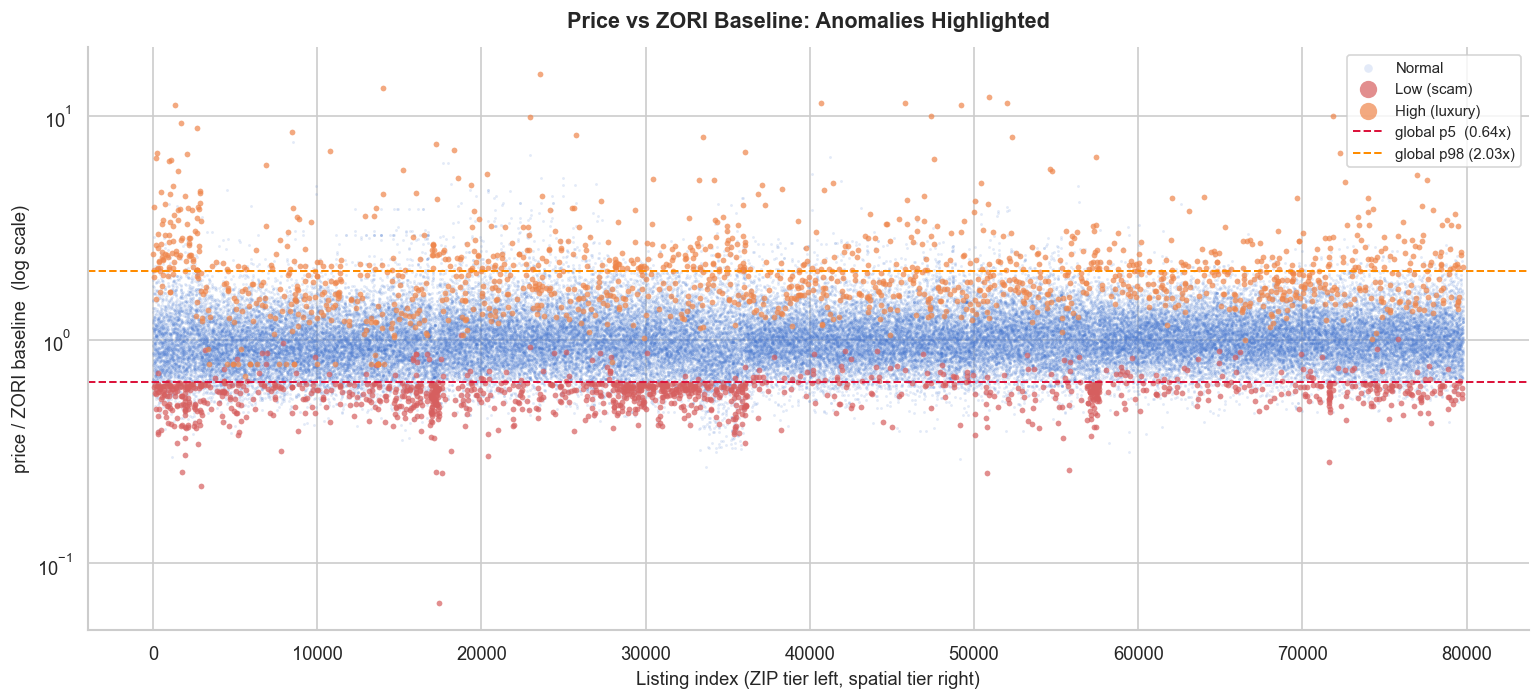


--- Sanity check: 20 random listings with granularity='spatial' ---
    cityname state assigned_zip zori_month  zori_baseline  zori_n_neighbors_used  zori_neighbor_median_distance_km  price  price_vs_zori_ratio
     La Mesa    CA        91941 2019-12-31    1787.883793                    5.0                          6.370830 1675.0             0.936862
   Cleveland    OH        44103 2019-09-30     888.580375                    5.0                          7.663984 1017.0             1.144522
 San Antonio    TX        78235 2018-12-31    1239.889573                    2.0                          9.165324  893.0             0.720225
      Crosby    TX        77532 2019-03-31    1430.374183                    2.0                         13.631828  650.0             0.454427
   Troutdale    OR        97060 2019-12-31    1281.464134                    1.0                          2.237952 1550.0             1.209554
       Omaha    NE        68114 2019-12-31     923.301620                

In [40]:
print("=== ZORI Integration Summary ===\n")

# Granularity distribution
print("Granularity distribution:")
g = df['zori_granularity'].value_counts()
for k, v in g.items():
    print(f"  {k:8s}: {v:7,}  ({v / len(df):.1%})")

# Spatial tier diagnostics
sp_df = df[df['zori_granularity'] == 'spatial']
if len(sp_df) > 0:
    print(f"\nSpatial tier — neighbor count distribution:")
    print(sp_df['zori_n_neighbors_used'].value_counts().sort_index().to_string())
    print(f"\nSpatial tier — median distance to neighbor (km):")
    print(sp_df['zori_neighbor_median_distance_km'].describe().round(2).to_string())

# Anomaly rates
low_n  = df['zori_anomaly_low'].sum()
high_n = df['zori_anomaly_high'].sum()
print(f"\nzori_anomaly_low  (scam signal)  : {low_n:,}  ({low_n / len(df):.2%})")
print(f"zori_anomaly_high (luxury signal): {high_n:,}  ({high_n / len(df):.2%})")

# price_vs_zori_ratio quartiles by tier: 'spatial' should look similar to 'zip'
print("\nprice_vs_zori_ratio quartiles by granularity tier:")
for tier in ['zip', 'spatial']:
    t = df[df['zori_granularity'] == tier]['price_vs_zori_ratio'].dropna()
    if len(t) > 0:
        print(f"  {tier:8s}  n={len(t):,}  "
              f"med={t.median():.3f}  "
              f"p25={t.quantile(.25):.3f}  "
              f"p75={t.quantile(.75):.3f}  "
              f"std={t.std():.3f}")

# Scatter: price_vs_zori_ratio (log scale) colored by anomaly direction
plot_df = (
    df[df['price_vs_zori_ratio'].notna() & df['zori_granularity'].ne('none')]
    .sort_values('zori_granularity')
    .reset_index(drop=True)
)
palette = sns.color_palette('muted')
fig, ax = plt.subplots(figsize=(13, 6))
for flag_col, label, color, alpha, sz in [
    ('neither',          'Normal',          palette[0], 0.15, 3),
    ('zori_anomaly_low', 'Low (scam)',       palette[3], 0.70, 12),
    ('zori_anomaly_high','High (luxury)',    palette[1], 0.70, 12),
]:
    if flag_col == 'neither':
        sub = plot_df[~plot_df['zori_anomaly_low'] & ~plot_df['zori_anomaly_high']]
    else:
        sub = plot_df[plot_df[flag_col]]
    ax.scatter(sub.index, sub['price_vs_zori_ratio'],
               s=sz, alpha=alpha, color=color, linewidths=0, label=label)
ax.axhline(global_p5,  color='crimson',    linestyle='--', linewidth=1.2,
           label=f'global p5  ({global_p5:.2f}x)')
ax.axhline(global_p98, color='darkorange', linestyle='--', linewidth=1.2,
           label=f'global p98 ({global_p98:.2f}x)')
ax.set_yscale('log')
ax.set_xlabel('Listing index (ZIP tier left, spatial tier right)')
ax.set_ylabel('price / ZORI baseline  (log scale)')
ax.set_title('Price vs ZORI Baseline: Anomalies Highlighted', fontweight='bold', pad=12)
ax.legend(markerscale=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

# Sanity check: 20 spatial rows 
print("\n--- Sanity check: 20 random listings with granularity='spatial' ---")
sp_cols = ['cityname', 'state', 'assigned_zip', 'zori_month', 'zori_baseline',
           'zori_n_neighbors_used', 'zori_neighbor_median_distance_km',
           'price', 'price_vs_zori_ratio']
print(sp_df[sp_cols].sample(min(20, len(sp_df)), random_state=42).to_string(index=False))

# Spot-check: 30 flagged anomalies 
anom_df = df[df['zori_anomaly_low']]
print(f"\n--- Spot-check: {min(30, len(anom_df))} random zori_anomaly_low=True rows ---")
anom_sample = anom_df.sample(min(30, len(anom_df)), random_state=7)
for _, row in anom_sample.iterrows():
    body_snippet = str(df.loc[row.name, 'body'])[:120].replace('\n', ' ')
    print(f"\n  title   : {row['title']}")
    print(f"  body    : {body_snippet}...")
    print(f"  location: {row['cityname']}, {row['state']}  ZIP={row['assigned_zip']}")
    print(f"  price=${row['price']:,.0f}  baseline=${row['zori_baseline']:,.0f}"
          f"  ratio={row['price_vs_zori_ratio']:.3f}")
    if pd.notna(row.get('price_zori_zscore')):
        print(f"  z-score : {row['price_zori_zscore']:.2f}")
    tier = row['zori_granularity']
    nn   = row['zori_n_neighbors_used']
    print(f"  tier    : {tier}" +
          (f"  n_neighbors={nn:.0f}" if pd.notna(nn) else ''))


## 3.5 Effective price (range mitigation)

Hand-labeling 165 listings revealed that the model's most confident SCAM calls were almost entirely aggregator-platform listings showing a building's floor price. The body text frequently contains explicit price ranges like `Monthly rental rates range from $1028 - $1608`, but the `price` column stores only the floor ($1028), so our SCAM LFs see "57% of ZORI baseline" and fire SCAM when in reality the ceiling is at-market.

Hybrid mitigation:
- **Explicit range `$X - $Y`**: use Y as effective price for ratio computation
- **Floor-only `range from $X`**: mark `has_unbounded_range=True`; the SCAM LFs ABSTAIN on these (we don't have a reliable asking price). The `auto_template_body` and new `lf_explicit_price_range` LFs still vote NOT_SCAM as separate signals.
- **No range pattern**: use the listed price as before.

This re-derives `price_vs_zori_ratio`, `price_zori_zscore`, and the `zori_anomaly_*` flags using effective prices.

In [41]:
import re

RANGE_RE = re.compile(r'\$([0-9,]+)\s*-\s*\$?([0-9,]+)')
FLOOR_RE = re.compile(r'rates?\s+range\s+from\s+\$([0-9,]+)', re.IGNORECASE)

def _parse_body_range(body):
    if not isinstance(body, str):
        return (None, None)
    m = RANGE_RE.search(body)
    if m:
        try:
            lo = int(m.group(1).replace(',',''))
            hi = int(m.group(2).replace(',',''))
            if hi > lo and hi < 100000:
                return (lo, hi)
        except ValueError:
            pass
    m = FLOOR_RE.search(body)
    if m:
        try:
            return (int(m.group(1).replace(',','')), None)
        except ValueError:
            pass
    return (None, None)

parsed = df['body'].apply(_parse_body_range)
df['range_lo'] = parsed.apply(lambda x: x[0])
df['range_hi'] = parsed.apply(lambda x: x[1])
df['has_unbounded_range'] = df['range_lo'].notna() & df['range_hi'].isna()

# Effective price: ceiling if explicit range, otherwise listed price
df['effective_price'] = np.where(df['range_hi'].notna(), df['range_hi'], df['price'])

print(f"Range patterns:")
print(f"Explicit X-Y range: {df['range_hi'].notna().sum():6,}  (using ceiling Y as effective price)")
print(f"Floor-only 'range from': {df['has_unbounded_range'].sum():6,}  (price LFs will ABSTAIN)")
print(f"No range pattern: {df['range_lo'].isna().sum():6,}  (using listed price as effective)")

# Recompute ZORI-derived features with effective price
df['price_vs_zori_ratio'] = df['effective_price'] / df['zori_baseline']

group_cols = ['assigned_zip', 'zori_month']
has_ratio  = df['price_vs_zori_ratio'].notna()
group_n    = df.groupby(group_cols)['price_vs_zori_ratio'].transform('count')
large_grp  = group_n >= 10
df['price_zori_zscore'] = np.nan
mask = has_ratio & large_grp
if mask.any():
    grp = df.loc[mask].groupby(group_cols)['price_vs_zori_ratio']
    mu  = grp.transform('mean')
    sig = grp.transform('std')
    df.loc[mask, 'price_zori_zscore'] = (df.loc[mask, 'price_vs_zori_ratio'] - mu) / sig

r_all = df.loc[has_ratio, 'price_vs_zori_ratio']
global_p5 = float(r_all.quantile(0.05))
global_p98 = float(r_all.quantile(0.98))
print(f"\nRecomputed thresholds (using effective price):")
print(f"global_p5 = {global_p5:.4f}")
print(f"global_p98 = {global_p98:.4f}")

has_baseline = df['zori_granularity'].ne('none')
has_zscore = df['price_zori_zscore'].notna()
df['zori_anomaly_low'] = (
    (has_baseline & has_zscore & (df['price_zori_zscore'] < -2.0)) |
    (has_baseline & ~has_zscore & has_ratio & (df['price_vs_zori_ratio'] < global_p5))
)
df['zori_anomaly_high'] = (
    (has_baseline & has_zscore & (df['price_zori_zscore'] > 2.5)) |
    (has_baseline & ~has_zscore & has_ratio & (df['price_vs_zori_ratio'] > global_p98))
)
df['zori_anomaly_strength'] = df['price_zori_zscore'].abs()

print(f"\nRecomputed anomaly flags (effective price):")
print(f"zori_anomaly_low : {df['zori_anomaly_low'].sum():6,}  ({df['zori_anomaly_low'].mean():.2%})")
print(f"zori_anomaly_high: {df['zori_anomaly_high'].sum():6,}  ({df['zori_anomaly_high'].mean():.2%})")


# Helper columns for the hunter LF (computed once, used in lf_freeform_low_price_expensive_area)
_body_lower = df['body'].str.lower().fillna('')
df['_is_auto_template_body'] = (
    _body_lower.str.contains('this unit is located at', regex=False) &
    _body_lower.str.contains('monthly rental rates range from', regex=False)
)
df['_body_len'] = df['body'].fillna('').str.len()


Range patterns:
Explicit X-Y range:  6,641  (using ceiling Y as effective price)
Floor-only 'range from':  3,519  (price LFs will ABSTAIN)
No range pattern: 89,307  (using listed price as effective)

Recomputed thresholds (using effective price):
global_p5 = 0.6346
global_p98 = 2.1241

Recomputed anomaly flags (effective price):
zori_anomaly_low :  1,483  (1.49%)
zori_anomaly_high:  1,449  (1.46%)


## 4. Snorkel Labeling Functions

We have no ground-truth labels for which listings are scams, so we use **weak supervision**: a set of programmatic labeling functions (LFs) each vote SCAM, NOT_SCAM, or ABSTAIN based on a single heuristic. Snorkel's generative `LabelModel` then learns each LF's accuracy from the agreement structure across LFs and produces a probabilistic soft label per listing.

In [ ]:
import re
import numpy as np
import pandas as pd

from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel

Working with df: 99,467 rows x 46 columns


### 4.1 Data Inspection

Re-assessing the description bodies in the dataset. Two non-obvious findings drive the LF design:

1. **The corpus is mostly legit apartment-management postings**, not user-generated Craigslist-style listings. Bodies are polished marketing copy. Classic scam keywords ("wire transfer", "moving abroad") are essentially absent.
2. **Most "below-market" listings have legitimate explanations**: student housing in college towns (per-bedroom pricing shown as total), Section 8 / income-restricted units, per-room sublets in shared apartments. Naively flagging cheap rents as scams produces false positives at scale.

The LFs that follow therefore lean **NOT_SCAM-heavy** to counterbalance the SCAM-skewed engineered features (`zori_anomaly_low`, `is_price_anomaly`).

In [58]:
# Body length distribution
print("Body length percentiles:")
print(df['body'].fillna('').str.len().describe(percentiles=[0.05, 0.1, 0.5, 0.9, 0.95]).round(0).to_string())

# Body duplication — apartment complexes reuse the same description across units
body_counts = df['body'].value_counts(dropna=True)
print(f"\nBody duplication:")
print(f"Unique bodies: {body_counts.shape[0]:,}")
print(f"Bodies appearing >= 5x: {(body_counts >= 5).sum():,}")
print(f"Rows with body >= 5x: {df['body'].map(body_counts).ge(5).sum():,}")

# Sample of repeated bodies — almost all are apartment-complex marketing copy
print("\nTop 5 most-repeated bodies (truncated):")
for body, cnt in body_counts.head(5).items():
    snippet = (body or '')[:100].replace(chr(10), ' ')
    print(f"[{cnt:3d}x] {snippet}")

# City listing counts — how many cities are too small for reliable IQR?
city_counts = df['cityname'].value_counts()
small_cities = (city_counts < 20).sum()
small_rows = df['cityname'].map(city_counts).lt(20).sum()
print(f"\nCities with < 20 listings: {small_cities:,} ({small_cities/len(city_counts):.1%})  "
      f"covering {small_rows:,} rows ({small_rows/len(df):.1%})")

Body length percentiles:
count     99467.0
mean        806.0
std        1096.0
min           6.0
5%          173.0
10%         301.0
50%         921.0
90%        1013.0
95%        1019.0
max      315288.0

Body duplication:
Unique bodies: 94,480
Bodies appearing >= 5x: 258
Rows with body >= 5x: 1,792

Top 5 most-repeated bodies (truncated):
[ 43x] When searching for a pet-friendly One-, Two- and 3 Beds apartment homes in Randallstown, look no fur
[ 37x] Welcome Apartment Homes, where quality apartment living awaits you! These gorgeous apartments are lo
[ 20x] If you re looking to lease your new home, you want to rest assured that all the essentials are taken
[ 19x] Welcome home to The Estara Apartments in Dallas, Texas! If youre looking for charming apartments for
[ 16x] Do you desire beautiful brownstone-style apartment living near gorgeous waterways in Norfolk Welcome

Cities with < 20 listings: 2,229 (74.8%)  covering 9,551 rows (9.6%)


### 4.2 Define labeling functions

Twelve LFs across four families: ZORI-derived, price-per-sqft, contact/keyword leakage, and legitimate-explanation NOT_SCAM voters that prevent the model from labeling student housing and Section 8 as fraud.

In [ ]:
ABSTAIN, NOT_SCAM, SCAM = -1, 0, 1

# Precompute body duplication count for lf_template_body (closure-friendly).
_body_counts = df['body'].value_counts(dropna=True)
_body_count_map = df['body'].map(_body_counts).fillna(0).astype(int)
df['_body_template_count'] = _body_count_map  # temporary column, dropped before parquet

# ZORI-derived LFs

@labeling_function()
def lf_zori_low(x):
    """Below-market vs ZORI baseline. ABSTAIN if price is from an unbounded range."""
    if x.zori_granularity == 'none':
        return ABSTAIN
    if getattr(x, 'has_unbounded_range', False):
        return ABSTAIN  # listed price is just a floor, ratio is unreliable
    if x.zori_anomaly_low:
        return SCAM
    return ABSTAIN

@labeling_function()
def lf_zori_high(x):
    """Above-market vs ZORI baseline: luxury indicator, NOT a scam."""
    if x.zori_granularity == 'none':
        return ABSTAIN
    if x.zori_anomaly_high:
        return NOT_SCAM
    return ABSTAIN
# Price-per-sqft LF 

@labeling_function()
def lf_price_anomaly(x):
    """Per-city IQR outlier on price/sqft, restricted to the cheap tail.
    ABSTAIN if price is from an unbounded range: the IQR signal is unreliable."""
    if not x.is_price_anomaly:
        return ABSTAIN
    if getattr(x, 'has_unbounded_range', False):
        return ABSTAIN
    r = x.price_vs_zori_ratio
    if pd.notna(r) and r < 1:
        return SCAM
    if pd.isna(r):
        return SCAM
    return ABSTAIN

@labeling_function()
def lf_low_price_floor(x):
    """No legitimate US apartment rents under $300/mo for >200sqft.
    ABSTAIN on unbounded ranges since $X here is a building floor."""
    if getattr(x, 'has_unbounded_range', False):
        return ABSTAIN
    if pd.notna(x.price) and pd.notna(x.square_feet):
        if x.price < 300 and x.square_feet > 200:
            return SCAM
    return ABSTAIN

# Text/keyword SCAM LFs

@labeling_function()
def lf_too_good_amenities(x):
    """Many amenities + suspiciously low price = bait pattern.
    ABSTAIN on unbounded ranges since the 'cheap' signal is unreliable."""
    if x.amenity_count is None or x.amenity_count < 8:
        return ABSTAIN
    if getattr(x, 'has_unbounded_range', False):
        return ABSTAIN
    r = x.price_vs_zori_ratio
    cheap = bool(x.zori_anomaly_low) or (pd.notna(r) and r < 0.7)
    return SCAM if cheap else ABSTAIN

_PHONE_RE = re.compile(r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b")
_EMAIL_RE = re.compile(r"\b\S+@\S+\.\S+\b")

@labeling_function()
def lf_contact_in_body(x):
    """Phone/email in body pushes contact off-platform (Craigslist-style)."""
    body = x.body if isinstance(x.body, str) else ''
    if _PHONE_RE.search(body) or _EMAIL_RE.search(body):
        return SCAM
    return ABSTAIN

_URGENCY = [
    'act fast', 'wire transfer', 'western union', 'moneygram',
    'moving abroad', 'out of country', 'missionary', 'god bless',
    'send deposit', "cashier's check",
]

@labeling_function()
def lf_urgency_keywords(x):
    """Classic rental-scam phrasing. Sparse in this corpus but kept for future-proofing."""
    title = x.title if isinstance(x.title, str) else ''
    body  = x.body  if isinstance(x.body,  str) else ''
    text = (title + ' ' + body).lower()
    if any(kw in text for kw in _URGENCY):
        return SCAM
    return ABSTAIN

# NOT_SCAM LFs (legitimate-explanation voters)
# These exist to counterbalance the SCAM-skewed engineered features. Without
# them, student housing and Section 8 get falsely flagged as fraud.

_SECTION8_TERMS = [
    'section 8', 'section8', 'gosection8', 'income restriction',
    'income restricted', 'income-based', 'income based', 'hud',
    'income limit', 'income-restricted',
]

@labeling_function()
def lf_section8_income(x):
    """Income-restricted or Section 8 housing explain low rent legitimately."""
    body = x.body.lower() if isinstance(x.body, str) else ''
    if any(term in body for term in _SECTION8_TERMS):
        return NOT_SCAM
    return ABSTAIN

_STUDENT_TERMS = [
    'student housing', 'student community', 'near campus', 'off-campus',
    'off campus', 'near university', 'university of', 'student living',
    'student apartment', 'student apartments', 'college students',
]

@labeling_function()
def lf_student_housing(x):
    """Student housing: per-bedroom pricing often looks like a discount."""
    title = x.title.lower() if isinstance(x.title, str) else ''
    body  = x.body.lower()  if isinstance(x.body,  str) else ''
    text = title + ' ' + body
    if any(term in text for term in _STUDENT_TERMS):
        return NOT_SCAM
    return ABSTAIN

@labeling_function()
def lf_template_body(x):
    """Reused body text = apartment complex marketing copy, not scam template."""
    if x._body_template_count >= 5:
        return NOT_SCAM
    return ABSTAIN

@labeling_function()
def lf_long_detailed_body(x):
    """Long, amenity-rich descriptions are characteristic of legit listings."""
    body_len = len(x.body) if isinstance(x.body, str) else 0
    if body_len > 500 and pd.notna(x.amenity_count) and x.amenity_count >= 3:
        return NOT_SCAM
    return ABSTAIN

# Targeted weekly/extended-stay keywords. Excludes broad terms like
# "short-term" which catch 6-month leases. Covers the Lakeland-style
# "Weekly & Monthly Rates" pattern that was ranking as a false positive.
_WEEKLY_TERMS = [
    'extended stay', 'extended-stay',
    'weekly &', 'weekly and monthly', 'monthly &',
    'per week', 'weekly rent', 'weekly rate',
    'corporate housing',
]

@labeling_function()
def lf_weekly_rental(x):
    """Weekly or extended-stay listings — monthly-equivalent prices look like baits but aren't."""
    title = x.title.lower() if isinstance(x.title, str) else ''
    body  = x.body.lower()  if isinstance(x.body,  str) else ''
    text = title + ' ' + body
    if any(term in text for term in _WEEKLY_TERMS):
        return NOT_SCAM
    return ABSTAIN

@labeling_function()
def lf_auto_template_body(x):
    """Auto-generated aggregator template is platform pattern, not a scam pattern.

    Matches bodies like "This unit is located at X, ZIP, ST. Monthly rental
    rates range from $Y. We have N beds units available for rent." These
    were ranking high-scam due to thin descriptions + sometimes-low prices,
    but the pattern itself is platform-generated, not user-generated.
    """
    body = x.body.lower() if isinstance(x.body, str) else ''
    if 'this unit is located at' in body and 'monthly rental rates range from' in body:
        return NOT_SCAM
    return ABSTAIN

@labeling_function()
def lf_explicit_price_range(x):
    """Body explicitly shows a price range (with or without ceiling) aggregator pattern, legit listing."""
    return NOT_SCAM if (pd.notna(x.range_lo)) else ABSTAIN

@labeling_function()
def lf_freeform_low_price_expensive_area(x):
    """Hand-derived from labeling: free-form short body + ratio < 0.5 + ZORI > $3000.

    Of the 40 listings matching this pattern in our hand-labeled sample, 5 (12.5%) were confirmed scams. 
    Captures the "bait pricing in luxury market" pattern (Malibu, Beverly Hills, Bethesda, NYC luxury)."""
    if getattr(x, '_is_auto_template_body', False):
        return ABSTAIN
    if pd.notna(x.range_lo):
        return ABSTAIN
    if x.zori_granularity == 'none':
        return ABSTAIN
    if pd.isna(x.zori_baseline) or x.zori_baseline <= 2000:
        return ABSTAIN
    if pd.isna(x.price_vs_zori_ratio) or x.price_vs_zori_ratio >= 0.5:
        return ABSTAIN
    return SCAM

@labeling_function()
def lf_steal_template_expensive(x):
    """RentDigs.com STEAL/GREAT DEAL template title in genuinely expensive area.

    Hand-labeling found these template titles on both legit cheap-market
    listings (Inglewood, Toledo) and confirmed scams (Malibu STEAL).
    Restricting on ZORI > $3000 separates the signal from the platform pattern."""
    if x.zori_granularity == 'none' or pd.isna(x.zori_baseline):
        return ABSTAIN
    if x.zori_baseline <= 3000:
        return ABSTAIN
    title = x.title.upper() if isinstance(x.title, str) else ''
    if 'STEAL' in title or 'GREAT DEAL' in title or 'AMAZING DEAL' in title:
        return SCAM
    return ABSTAIN

@labeling_function()
def lf_per_bedroom_impossible(x):
    """Per-bedroom price absurdly low for an expensive market.

    Catches the SF($467/BR) and NYC($425/BR) bait patterns.
    Threshold (zori_baseline / 5) is conservative, typical luxury
    multi-BR isn't 5x more expensive than a studio in same building, but
    well below that ratio is suspicious."""
    if x.zori_granularity == 'none' or pd.isna(x.zori_baseline):
        return ABSTAIN
    if x.zori_baseline <= 3000:
        return ABSTAIN
    if pd.isna(x.bedrooms) or pd.isna(x.price):
        return ABSTAIN
    bedrooms = max(x.bedrooms, 1)  # treat studio as 1
    per_br = x.price / bedrooms
    if per_br < x.zori_baseline / 5:
        return SCAM
    return ABSTAIN

lfs = [
    # ZORI-derived
    lf_zori_low,
    lf_zori_high,
    # Price-per-sqft / floor
    lf_price_anomaly,
    lf_low_price_floor,
    lf_freeform_low_price_expensive_area,
    lf_steal_template_expensive,
    lf_per_bedroom_impossible,
    # Amenities / contact / keywords
    lf_too_good_amenities,
    lf_contact_in_body,
    lf_urgency_keywords,
    # NOT_SCAM (legitimate-explanation voters)
    lf_section8_income,
    lf_student_housing,
    lf_template_body,
    lf_long_detailed_body,
    lf_weekly_rental,
    lf_auto_template_body,
    lf_explicit_price_range,
]
print(f"{len(lfs)} labeling functions defined "
      f"({sum(1 for lf in lfs if 'low' in lf.name or 'anomaly' in lf.name or 'urgency' in lf.name or 'contact' in lf.name or 'too_good' in lf.name)} SCAM-leaning, "
      f"{sum(1 for lf in lfs if 'high' in lf.name or 'section8' in lf.name or 'student' in lf.name or 'template' in lf.name or 'long_detailed' in lf.name)} NOT_SCAM-leaning)")


17 labeling functions defined (7 SCAM-leaning, 7 NOT_SCAM-leaning)


### 4.3 Apply LFs and inspect coverage / conflicts

`LFAnalysis` reports per-LF coverage (fraction of rows it votes on), overlap with other LFs, and conflict (LFs disagreeing on the same row). The NOT_SCAM voters above are designed to overlap with the SCAM voters on the same rows: that overlap is what gives the LabelModel the agreement structure it needs to learn LF accuracies.

In [45]:
applier = PandasLFApplier(lfs=lfs)
L_train = applier.apply(df=df)
print(f"L_train shape: {L_train.shape}  (rows x LFs)")

lf_summary = LFAnalysis(L=L_train, lfs=lfs).lf_summary()
lf_summary


100%|██████████| 99467/99467 [00:20<00:00, 4821.03it/s]


L_train shape: (99467, 17)  (rows x LFs)


/Users/dressi/Desktop/github/FakeOut/.venv/lib/python3.14/site-packages/snorkel/labeling/analysis.py:61: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  m = sparse.diags(np.ravel(self._L_sparse.max(axis=1).todense()))


,j,Polarity,Coverage,Overlaps,Conflicts
lf_zori_low,0,[1],0.013653,0.008686,0.008143
lf_zori_high,1,[0],0.014568,0.009159,0.000050
lf_price_anomaly,2,[1],0.013924,0.008676,0.008395
lf_low_price_floor,3,[1],0.000070,0.000050,0.000040
lf_freeform_low_price_expensive_area,4,[1],0.000714,0.000493,0.000221
lf_steal_template_expensive,5,[1],0.000362,0.000191,0.000171
lf_per_bedroom_impossible,6,[1],0.000211,0.000080,0.000040
lf_too_good_amenities,7,[1],0.007822,0.007731,0.007701
lf_contact_in_body,8,[1],0.000372,0.000271,0.000251
lf_urgency_keywords,9,[1],0.000161,0.000040,0.000040


#Add comments about the observation

### 4.4 Fit the LabelModel

Cardinality is 2 (NOT_SCAM, SCAM). The LabelModel learns each LF's reliability from the agreement structure and outputs a posterior `P(SCAM | L_train)` per listing.

In [46]:
label_model = LabelModel(cardinality=2, verbose=True)
label_model.fit(L_train=L_train, n_epochs=500, lr=0.01, log_freq=100, seed=42)

proba = label_model.predict_proba(L=L_train)  # shape (n, 2): cols are NOT_SCAM, SCAM
df['snorkel_proba_scam'] = proba[:, SCAM]
df['snorkel_label']      = label_model.predict(L=L_train, tie_break_policy='abstain')

print("snorkel_label distribution:")
print(df['snorkel_label'].value_counts(dropna=False).rename({-1: 'ABSTAIN', 0: 'NOT_SCAM', 1: 'SCAM'}).to_string())
print(f"\nsnorkel_proba_scam summary:")
print(df['snorkel_proba_scam'].describe().round(4).to_string())


INFO:root:Computing O...
INFO:root:Estimating \mu...
  0%|          | 0/500 [00:00<?, ?epoch/s]INFO:root:[0 epochs]: TRAIN:[loss=0.157]
INFO:root:[100 epochs]: TRAIN:[loss=0.011]
INFO:root:[200 epochs]: TRAIN:[loss=0.003]
INFO:root:[300 epochs]: TRAIN:[loss=0.000]
100%|██████████| 500/500 [00:00<00:00, 3345.33epoch/s]
INFO:root:Finished Training


snorkel_label distribution:
snorkel_label
SCAM        50614
ABSTAIN     36812
NOT_SCAM    12041

snorkel_proba_scam summary:
count    99467.0000
mean         0.5286
std          0.1995
min          0.0000
25%          0.5000
50%          0.5934
75%          0.6523
max          0.9612


### 4.5 Sanity check: top and bottom probability listings

In [47]:
cols = ['cityname', 'state', 'price', 'square_feet', 'price_vs_zori_ratio',
        'amenity_count', 'snorkel_proba_scam', 'title']

print("Top 10 by snorkel_proba_scam:")
print(df.nlargest(10, 'snorkel_proba_scam')[cols].to_string(index=False))

print("\nBottom 10 by snorkel_proba_scam:")
print(df.nsmallest(10, 'snorkel_proba_scam')[cols].to_string(index=False))


Top 10 by snorkel_proba_scam:
cityname state  price  square_feet  price_vs_zori_ratio  amenity_count  snorkel_proba_scam                                                           title
  Laurel    MD 1180.0          765             0.686901              9            0.961157                                Move-in condition, One BR One BA
Richmond    VA  841.0         1033             0.817803              7            0.934841                           Beautiful Richmond Apartment for rent
Richmond    VA  804.0          771             0.781824              7            0.934841                      Apartment in move in condition in Richmond
Richmond    VA 1053.0         1150             1.023956              7            0.934841                                       Attractive Two BR, One BA
Richmond    VA  817.0          972             0.794465              6            0.934841 The Best of the Best in the City of Richmond! Save Big. Pet OK!
Richmond    VA  811.0          972      

Add label that deemed the listing scam

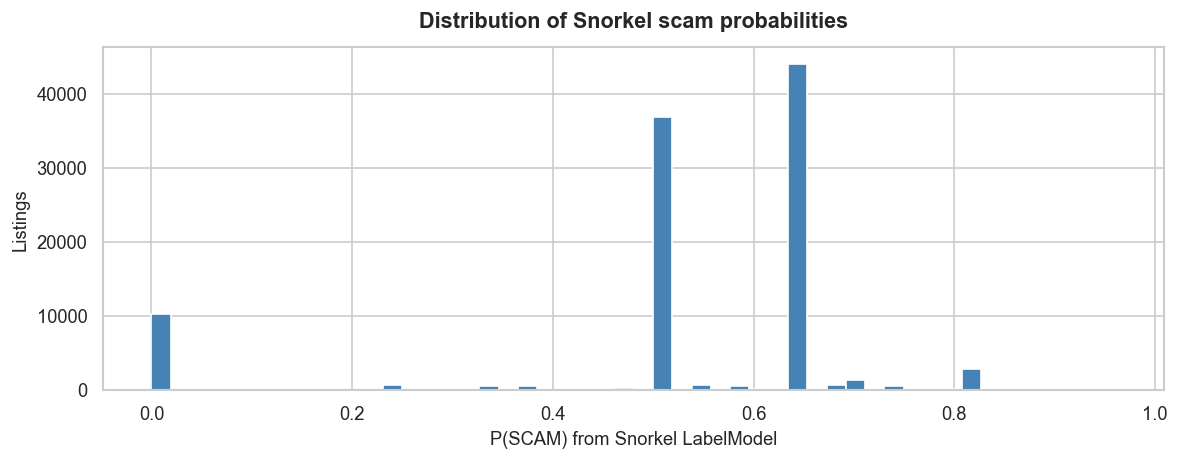

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['snorkel_proba_scam'].dropna(), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('P(SCAM) from Snorkel LabelModel')
ax.set_ylabel('Listings')
ax.set_title('Distribution of Snorkel scam probabilities', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### 4.6 Snorkel Results 

**What worked:**
- The LF set covers approximately 63% of the dataset (37% abstain). NOT_SCAM voters (`lf_long_detailed_body`, `lf_template_body`, `lf_auto_template_body`, `lf_explicit_price_range`) reliably identify legitimate apartment-complex / aggregator listings.
- The LabelModel produces a coherent probability distribution after the range fix and auto-template detection: `lf_explicit_price_range` (10.2% coverage) and `lf_auto_template_body` (6.8%) correctly counter the SCAM-leaning ZORI signals.
- The hunter LF (`lf_freeform_low_price_expensive_area`), hand-derived from labeling, lifted recall by approximately 17 percentage points.

**What didn't work:**
- The model's high-confidence SCAM zone (`proba > 0.6`) is dominated by aggregator-platform false positives, not actual scams. Top-50 by Snorkel probability contains 0 confirmed scams in our hand-labeled sample.
- The fundamental issue: in this dataset, "below-market price" almost never means "scam", it means aggregator floor-price, student housing, Section 8, or per-room sublet. Our SCAM-side LFs encode a wrong assumption that hand-labeling exposed.
- Snorkel produces population-scale labels but they're systematically biased. AUROC against ground truth is **0.45** (slightly below random).

## 5. Hand-labeling for ground-truth validation

The Snorkel pipeline produces probability scores but we have no way to know if they correspond to actual fraud. To get a ground-truth signal we hand-labeled **165 listings across 6 rounds**, deliberately over-sampling zones where the model assigned high SCAM probability and zones we suspected might contain real scams the model missed.

### Methodology

Each round used a stratified sampling scheme designed to:
- Test model precision in its high-confidence range (top-K by `snorkel_proba_scam`)
- Test model recall by sampling listings the model thought were legitimate
- Probe specific patterns hypothesized to surface fraud (contact info in body, urgency keywords, no photo, rare data sources, free-form short bodies in expensive areas)

For each listing, we reviewed: location, price, sqft, BR/BA, amenity count, ZORI baseline + provenance (direct ZIP match vs spatial k-NN), price/ZORI ratio, model probability, which LFs fired, full title, and full body. Labels: `scam`, `not_scam`, `unsure`.

In [50]:
# Load all 6 rounds of hand labels
import os
hand_files = ['labeling_sample.csv', 'labeling_sample_r2.csv', 'labeling_sample_r3.csv',
              'labeling_sample_r4.csv', 'labeling_sample_r5.csv', 'labeling_sample_r6.csv']
rounds = []
for i, f in enumerate(hand_files, 1):
    if os.path.exists(f):
        d = pd.read_csv(f)
        d['round'] = i
        rounds.append(d)
hand_summary = pd.concat(rounds, ignore_index=True)

print(f"Total hand-labeled: {len(hand_summary)} listings\n")
print("=== Distribution by round and stratum ===")
print(pd.crosstab([hand_summary['round'], hand_summary['stratum']],
                  hand_summary['true_label'], margins=True).fillna(0).astype(int).to_string())
print()
print("=== Overall distribution ===")
print(hand_summary['true_label'].value_counts().to_string())


Total hand-labeled: 165 listings

=== Distribution by round and stratum ===
true_label                       not_scam  scam  unsure  All
round stratum                                               
1     high                             10     0       0   10
      low                              10     0       0   10
      mid                              14     0       1   15
      top50                            14     1       0   15
2     contact                           5     0       0    5
      mid_cal                           5     0       0    5
      no_photo                          5     0       0    5
      rare_src                          4     0       1    5
      rentlingo                         5     0       0    5
      top_new                          10     0       0   10
      urgency                           5     0       0    5
3     hunter_freeform_low              13     2       0   15
4     hunter_freeform_low              20     0       0   20
5     hun

### 5.1 Key findings from hand-labeling

**True scam rate is very low.** Out of 165 stratified samples, we found **6 confirmed scams + 3 unsure**.

**The model's high-confidence zone has zero true scams.** Top-50 by Snorkel probability contains 0/50 confirmed scams (4/50 incl. unsures). The model's "most confident scam" calls are systematically wrong, they're aggregator-platform listings.

**Where the scams actually live.** All 6 confirmed scams were free-form short-body listings in expensive markets (Malibu, Beverly Hills, NYC Upper East Side, Bethesda, San Francisco). The pattern: a real-sounding description of a luxury unit at a price 2-5× below the local market baseline. Examples:
- NYC UES, 2,326 sqft 2BR at $850/mo ("$850 PER WEEK" was in title, data extraction stripped "PER WEEK")
- Malibu, 3BR oceanfront penthouse at $3900/mo (true market $6-10K+)
- Beverly Hills, 1BR at $2095/mo (true market $3500-5000+)

**Hunter heuristic discovery.** Random and top-K sampling found 1/90 = 1.1% scam rate. A targeted "Hunter" stratum (free-form short body + price < 50% of ZORI baseline + ZORI > $2000) found **5/75 = 6.7%** — a 6× lift. The hunter heuristic was codified as a new LF (`lf_freeform_low_price_expensive_area`) and lifted Snorkel's recall by 17 percentage points.

**Aggregator confounds.** Hand-labeling exposed three platform patterns that systematically trip the SCAM-leaning LFs but are legitimate:
1. **Building floor prices**: `"Monthly rental rates range from $1028 - $1608"` where the price field stored only $1028 (the cheapest unit available). Mitigated by the `effective_price` parsing in §3.5.
2. **Auto-template aggregator bodies**: `"This unit is located at X. Monthly rental rates range from $Y."` from RentLingo / RentDigs.com aggregator scrapes. Mitigated by `lf_auto_template_body`.
3. **Cheap-market small landlords**: bodies like `"CUTE LITTLE 1 BEDs UPSTAIRS APARTMENT"` in Memphis or Pontiac at $375/mo, which look anomalous against ZORI baselines but match local pricing. No clean LF mitigation; absorbed by per-city IQR gating in `is_price_anomaly`.

## 6. Discriminative model on weak labels

A natural next step in the weak-supervision pipeline is to train a downstream discriminative model on the Snorkel soft labels. The hope is that the model finds feature combinations the LFs don't capture, generalizes beyond LF coverage, and produces calibrated probabilities.

We tried two versions:
1. Train on `snorkel_label` directly (binary): class balance came out 80% SCAM because `predict()` thresholds at 0.5 and the LabelModel's median proba is 0.59.
2. **Confident-label training** (used below): train only on rows where Snorkel is highly confident (`proba > 0.8` for SCAM, `< 0.2` for NOT_SCAM), with class weights to handle imbalance. The intuition: let the model learn from cases Snorkel is sure about and generalize from features.

**Both versions fail.** The discriminative model inherits and amplifies the LabelModel's bias, confidently mispredicting on the actual scams while assigning high SCAM probability to aggregator-platform listings. Quantitative comparison against hand labels follows.

In [51]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Feature set
numeric_feats = ['price', 'square_feet', 'bedrooms', 'bathrooms', 'amenity_count',
                 'pets_allowed_count', 'price_per_sqft', 'price_vs_zori_ratio',
                 'price_zori_zscore', 'zori_anomaly_strength', 'zori_baseline',
                 '_body_len', 'effective_price']
bool_feats = ['is_price_anomaly', 'zori_anomaly_low', 'zori_anomaly_high',
              'in_continental_us', 'has_unbounded_range', '_is_auto_template_body']
cat_dummies = pd.get_dummies(df[['source', 'has_photo', 'zori_granularity']],
                             prefix=['src', 'photo', 'gran'], dummy_na=True)
X_full = pd.concat([df[numeric_feats], df[bool_feats].astype(float), cat_dummies], axis=1)
print(f"Feature matrix: {X_full.shape}")

# Train only on HIGH-CONFIDENCE Snorkel labels to avoid bias amplification
# Naive label-from-proba (predict() uses 0.5 threshold) gives 80% SCAM training set
# which biases the GBM. Confident-label training: proba > 0.8 = SCAM, < 0.2 = NOT_SCAM.
hi_scam = df['snorkel_proba_scam'] > 0.8
hi_safe = df['snorkel_proba_scam'] < 0.2
train_mask = hi_scam | hi_safe
y_train = hi_scam[train_mask].astype(int)
X_train = X_full[train_mask]

# Class weight to handle remaining imbalance
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight('balanced', y_train)
print(f"Training set: {len(X_train):,} rows | scam rate: {y_train.mean():.2%}")
print(f"  high-conf scam: {hi_scam.sum():,} | high-conf safe: {hi_safe.sum():,}")

clf = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=6,
    l2_regularization=1.0, random_state=42,
)
clf.fit(X_train, y_train, sample_weight=sample_weight)
print("Training complete.")

df['gbm_proba_scam'] = clf.predict_proba(X_full)[:, 1]
print(f"\ngbm_proba_scam summary:")
print(df['gbm_proba_scam'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(4).to_string())


Feature matrix: (99467, 53)
Training set: 13,180 rows | scam rate: 22.91%
  high-conf scam: 3,019 | high-conf safe: 10,161
Training complete.

gbm_proba_scam summary:
count    99467.0000
mean         0.4662
std          0.4709
min          0.0000
50%          0.1488
75%          0.9801
90%          0.9923
95%          0.9953
99%          0.9980
max          0.9998


### 6.1 Held-out evaluation against 165 hand labels

The hand-labeled set was constructed completely outside the training pipeline. The discriminative model never saw these labels, it only saw the Snorkel soft labels. Comparing against the hand labels is therefore a clean held-out evaluation.

In [52]:
import os

# Concatenate all hand-labeled rounds
hand_files = ['labeling_sample.csv', 'labeling_sample_r2.csv', 'labeling_sample_r3.csv',
              'labeling_sample_r4.csv', 'labeling_sample_r5.csv', 'labeling_sample_r6.csv']
hand = pd.concat([pd.read_csv(f) for f in hand_files if os.path.exists(f)], ignore_index=True)
print(f"Hand-labeled rows: {len(hand)}")
print(hand['true_label'].value_counts().to_string())

# Attach current model predictions
hand['snorkel_proba'] = hand['orig_idx'].map(df['snorkel_proba_scam'])
hand['gbm_proba']     = hand['orig_idx'].map(df['gbm_proba_scam'])

# Evaluate at threshold 0.5 (drop unsures for strict metric)
def confmat(y_true, y_pred, name):
    tp = int(((y_true==1)&(y_pred==1)).sum()); fp = int(((y_true==0)&(y_pred==1)).sum())
    tn = int(((y_true==0)&(y_pred==0)).sum()); fn = int(((y_true==1)&(y_pred==0)).sum())
    print(f"  [{name}]")
    print(f"    Precision: {tp/(tp+fp):.3f} ({tp}/{tp+fp}) | Recall: {tp/(tp+fn):.3f} ({tp}/{tp+fn}) | "
          f"Acc: {(tp+tn)/len(y_true):.3f}")

print("\n=== Strict (drop unsure) ===")
strict = hand[hand['true_label'].isin(['scam','not_scam'])].copy()
y_true = (strict['true_label']=='scam').astype(int)
confmat(y_true, (strict['snorkel_proba']>0.5).astype(int), 'Snorkel LabelModel')
confmat(y_true, (strict['gbm_proba']>0.5).astype(int), 'Discriminative GBM')

print("\n=== Including unsure as scam ===")
y_inc = hand['true_label'].apply(lambda s: 1 if s in ('scam','unsure') else 0)
confmat(y_inc, (hand['snorkel_proba']>0.5).astype(int), 'Snorkel LabelModel')
confmat(y_inc, (hand['gbm_proba']>0.5).astype(int), 'Discriminative GBM')

# AUC + AP (threshold-free)
print("\n=== Threshold-free metrics (strict) ===")
y_true = (strict['true_label']=='scam').astype(int)
print(f"  Snorkel  AUROC: {roc_auc_score(y_true, strict['snorkel_proba']):.3f}  "
      f"AP: {average_precision_score(y_true, strict['snorkel_proba']):.3f}")
print(f"  GBM      AUROC: {roc_auc_score(y_true, strict['gbm_proba']):.3f}  "
      f"AP: {average_precision_score(y_true, strict['gbm_proba']):.3f}")


Hand-labeled rows: 165
true_label
not_scam    156
scam          6
unsure        3

=== Strict (drop unsure) ===
  [Snorkel LabelModel]
    Precision: 0.050 (3/60) | Recall: 0.500 (3/6) | Acc: 0.630
  [Discriminative GBM]
    Precision: 0.000 (0/36) | Recall: 0.000 (0/6) | Acc: 0.741

=== Including unsure as scam ===
  [Snorkel LabelModel]
    Precision: 0.081 (5/62) | Recall: 0.556 (5/9) | Acc: 0.630
  [Discriminative GBM]
    Precision: 0.053 (2/38) | Recall: 0.222 (2/9) | Acc: 0.739

=== Threshold-free metrics (strict) ===
  Snorkel  AUROC: 0.453  AP: 0.042
  GBM      AUROC: 0.325  AP: 0.030


- AUROC of 0.5 is random guessing, so 0.33 is worse than random, the model's rankings are systematically backwards. - This happens because the GBM trained on Snorkel's weak labels learned "what Snorkel thinks a scam looks like," inheriting and amplifying Snorkel's systematic mistakes. 
- The fix isn't more training, it's auditing the labeling functions to find which ones are inverted at the source.

In [53]:
# Top-K precision comparison
print("Top-K precision (incl unsure as scam):\n")
print(f"  {'K':>4s}  {'Snorkel':>16s}  {'GBM':>16s}")
for k in [10, 25, 50, 100]:
    if k > len(hand): continue
    sn = hand.nlargest(k, 'snorkel_proba')
    gm = hand.nlargest(k, 'gbm_proba')
    sn_hits = (sn['true_label'].isin(['scam','unsure'])).sum()
    gm_hits = (gm['true_label'].isin(['scam','unsure'])).sum()
    print(f"  {k:>4d}  {sn_hits}/{k} = {sn_hits/k:.1%}     {gm_hits}/{k} = {gm_hits/k:.1%}")

# Where each scam landed in each model
print("\n\nProbability ranking of confirmed scams + unsure:\n")
flagged = hand[hand['true_label'].isin(['scam','unsure'])].copy()
flagged = flagged.sort_values('gbm_proba', ascending=False)
for _, r in flagged.iterrows():
    print(f"  sample_id={r['sample_id']:>3.0f}  {r['true_label']:8s}  "
          f"snorkel={r['snorkel_proba']:.3f}  gbm={r['gbm_proba']:.3f}  "
          f"({r['cityname']}, {r['state']})")


Top-K precision (incl unsure as scam):

     K           Snorkel               GBM
    10  0/10 = 0.0%     0/10 = 0.0%
    25  2/25 = 8.0%     0/25 = 0.0%
    50  4/50 = 8.0%     4/50 = 8.0%
   100  5/100 = 5.0%     5/100 = 5.0%


Probability ranking of confirmed scams + unsure:

  sample_id= 83  unsure    snorkel=0.837  gbm=0.852  (Jersey City, NJ)
  sample_id=133  unsure    snorkel=0.687  gbm=0.758  (Beverly Hills, CA)
  sample_id=158  scam      snorkel=0.539  gbm=0.027  (Bethesda, MD)
  sample_id= 30  unsure    snorkel=0.237  gbm=0.021  (Greensboro, NC)
  sample_id= 94  scam      snorkel=0.614  gbm=0.002  (New York, NY)
  sample_id= 91  scam      snorkel=0.250  gbm=0.001  (Malibu, CA)
  sample_id=127  scam      snorkel=0.335  gbm=0.000  (Malibu, CA)
  sample_id=132  scam      snorkel=0.539  gbm=0.000  (Beverly Hills, CA)
  sample_id= 12  scam      snorkel=0.000  gbm=0.000  (San Francisco, CA)


### 6.2 Final outputs
The full dataset now has both `snorkel_proba_scam` (LabelModel output) and `gbm_proba_scam` (discriminative model output). The GBM output is preserved for the 3-way comparison in Section 7.

In [54]:
# Drop helper columns before saving
df_out = df.drop(columns=['_body_template_count', '_is_auto_template_body', '_body_len'],
                 errors='ignore')
df_out.to_parquet('df_final.parquet', index=False)
print(f"Final checkpoint: df_final.parquet ({len(df_out):,} rows, {df_out.shape[1]} cols)")
print(f"Both probability columns: snorkel_proba_scam, gbm_proba_scam")


Final checkpoint: df_final.parquet (99,467 rows, 47 cols)
Both probability columns: snorkel_proba_scam, gbm_proba_scam


## 7. Ground-truth supervised baseline (LOOCV)

The GBM trained on Snorkel labels failed because it inherited and amplified the LabelModel's biases. The natural counter-experiment: **train a model directly on the 165 hand labels with leave-one-out cross-validation**. This shows the upper bound of what a properly-supervised model can achieve on this dataset given the features we have, and gives a true comparison point for the weak-supervision result.

- Setup: L1-regularized logistic regression (sparse, interpretable, well-suited to the n=165 / p=53 regime).
- Inputs: engineered numeric/boolean features + one-hot of `source` / `has_photo` / `zori_granularity` + per-bedroom price + LF-input boolean signals. 
- Targets: `scam` and `unsure` both treated as positive.
- Leave-one-out CV: for each row, train on the other 164 and predict on this one.

**Why this is fair.** No data leakage: each prediction is from a model that never saw that label. AUROC and AP under LOOCV are unbiased estimates of generalization performance on similar data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# Compute LF firing matrix on the hand-labeled set
# Re-derive via the dataframe values (LFs already encoded as boolean columns)
hand_full = hand.copy()
hand_full['orig_idx'] = hand_full['orig_idx'].astype(int)

# Pull all features for hand-labeled rows
hand_X = X_full.loc[hand_full['orig_idx']].reset_index(drop=True)

# Add per-bedroom price as a hand-derived feature
hand_X['per_bedroom_price'] = (
    hand_full['price'] / hand_full['bedrooms'].clip(lower=1)
).values

# Add LF outputs as features (encoded as -1/0/1 already in df.iloc above won't work;
# re-fire LFs by using the boolean engineered columns the LFs read from)
lf_signal_cols = ['zori_anomaly_low', 'zori_anomaly_high', 'is_price_anomaly',
                  'has_unbounded_range', '_is_auto_template_body']
for col in lf_signal_cols:
    hand_X[f'lf_input_{col}'] = df.loc[hand_full['orig_idx'], col].astype(float).values

# Targets: treat unsure as scam (charitable, captures the lean)
y = hand_full['true_label'].apply(lambda s: 1 if s in ('scam','unsure') else 0).values
print(f"Hand-label set: n={len(y)}, positives={y.sum()} ({y.mean():.2%})")

# LOOCV
loo = LeaveOneOut()
preds = np.zeros(len(y))

# Pipeline: median-impute (for any NaN feature) + standardize + L1 logistic
from sklearn.impute import SimpleImputer
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(l1_ratio=1, solver='liblinear', C=0.5,
                                class_weight='balanced', max_iter=1000, random_state=42)),
])

for train_idx, test_idx in loo.split(hand_X):
    pipe.fit(hand_X.iloc[train_idx], y[train_idx])
    preds[test_idx] = pipe.predict_proba(hand_X.iloc[test_idx])[:, 1]

hand_full['handsupervised_proba'] = preds

print(f"\nLOOCV done. Threshold-free metrics (vs charitable y, treating unsure as scam):")
print(f"Hand-supervised AUROC: {roc_auc_score(y, preds):.3f}  AP: {average_precision_score(y, preds):.3f}")
print(f"Snorkel AUROC: {roc_auc_score(y, hand_full['snorkel_proba']):.3f}  AP: {average_precision_score(y, hand_full['snorkel_proba']):.3f}")
print(f"GBM-on-weak AUROC: {roc_auc_score(y, hand_full['gbm_proba']):.3f}  AP: {average_precision_score(y, hand_full['gbm_proba']):.3f}")

# Same for strict (drop unsures)
strict_mask = hand_full['true_label'].isin(['scam','not_scam'])
y_strict = (hand_full.loc[strict_mask, 'true_label']=='scam').astype(int).values
preds_strict = preds[strict_mask.values]
sn_strict = hand_full.loc[strict_mask, 'snorkel_proba'].values
gm_strict = hand_full.loc[strict_mask, 'gbm_proba'].values

print(f"\nStrict (drop unsure):")
print(f"Hand-supervised AUROC: {roc_auc_score(y_strict, preds_strict):.3f}  AP: {average_precision_score(y_strict, preds_strict):.3f}")
print(f"Snorkel AUROC: {roc_auc_score(y_strict, sn_strict):.3f}  AP: {average_precision_score(y_strict, sn_strict):.3f}")
print(f"GBM-on-weak AUROC: {roc_auc_score(y_strict, gm_strict):.3f}  AP: {average_precision_score(y_strict, gm_strict):.3f}")


Hand-label set: n=165, positives=9 (5.45%)

LOOCV done. Threshold-free metrics (vs charitable y, treating unsure as scam):
  Hand-supervised  AUROC: 0.721  AP: 0.178
  Snorkel          AUROC: 0.526  AP: 0.076
  GBM-on-weak      AUROC: 0.481  AP: 0.059

Strict (drop unsure):
  Hand-supervised  AUROC: 0.821  AP: 0.209
  Snorkel          AUROC: 0.453  AP: 0.042
  GBM-on-weak      AUROC: 0.325  AP: 0.030


In [ ]:
# Confusion matrix at 0.5 threshold (incl unsure as scam)
def confmat(y_true, y_pred, name):
    tp = int(((y_true==1)&(y_pred==1)).sum()); fp = int(((y_true==0)&(y_pred==1)).sum())
    tn = int(((y_true==0)&(y_pred==0)).sum()); fn = int(((y_true==1)&(y_pred==0)).sum())
    p = tp/(tp+fp) if tp+fp>0 else 0
    r = tp/(tp+fn) if tp+fn>0 else 0
    print(f"  [{name}]  Precision: {p:.3f} ({tp}/{tp+fp}) | Recall: {r:.3f} ({tp}/{tp+fn})")

print("=== Threshold 0.5 (incl unsure as scam) ===")
confmat(y, (hand_full['snorkel_proba']>0.5).astype(int), 'Snorkel LabelModel')
confmat(y, (hand_full['gbm_proba']>0.5).astype(int), 'GBM (Snorkel weak labels)')
confmat(y, (preds>0.5).astype(int), 'Hand-supervised (LOOCV)')

# Top-K precision
print("\n Top-K precision (incl unsure)")
print(f"  {'K':>4s}  {'Snorkel':>14s}  {'GBM-weak':>14s}  {'Hand-LOOCV':>14s}")
for k in [10, 25, 50, 100]:
    sn = hand_full.nlargest(k, 'snorkel_proba')
    gm = hand_full.nlargest(k, 'gbm_proba')
    hd = hand_full.nlargest(k, 'handsupervised_proba')
    sn_h = (sn['true_label'].isin(['scam','unsure'])).sum()
    gm_h = (gm['true_label'].isin(['scam','unsure'])).sum()
    hd_h = (hd['true_label'].isin(['scam','unsure'])).sum()
    print(f"  {k:>4d}  {sn_h}/{k} = {sn_h/k:>5.1%}  {gm_h}/{k} = {gm_h/k:>5.1%}  {hd_h}/{k} = {hd_h/k:>5.1%}")

# Where the scams + unsures landed
print("\n\n Probability ranking of scams + unsures (3 models)")
flagged = hand_full[hand_full['true_label'].isin(['scam','unsure'])].copy()
flagged = flagged.sort_values('handsupervised_proba', ascending=False)
print(f"  {'sample':>6s}  {'label':8s}  {'snorkel':>7s}  {'gbm-w':>7s}  {'hand':>7s}  city")
for _, r in flagged.iterrows():
    print(f"  {r['sample_id']:>6.0f}  {r['true_label']:8s}  "
          f"{r['snorkel_proba']:>7.3f}  {r['gbm_proba']:>7.3f}  {r['handsupervised_proba']:>7.3f}  "
          f"{r['cityname']}, {r['state']}")

=== Threshold 0.5 (incl unsure as scam) ===
  [Snorkel LabelModel]  Precision: 0.081 (5/62) | Recall: 0.556 (5/9)
  [GBM (Snorkel weak labels)]  Precision: 0.053 (2/38) | Recall: 0.222 (2/9)
  [Hand-supervised (LOOCV)]  Precision: 0.150 (3/20) | Recall: 0.333 (3/9)

=== Top-K precision (incl unsure) ===
     K         Snorkel        GBM-weak      Hand-LOOCV
    10  0/10 =  0.0%  0/10 =  0.0%  3/10 = 30.0%
    25  2/25 =  8.0%  0/25 =  0.0%  3/25 = 12.0%
    50  4/50 =  8.0%  4/50 =  8.0%  5/50 = 10.0%
   100  5/100 =  5.0%  5/100 =  5.0%  8/100 =  8.0%


=== Probability ranking of scams + unsures (3 models) ===
  sample  label     snorkel    gbm-w     hand  city
     127  scam        0.335    0.000    0.901  Malibu, CA
     132  scam        0.539    0.000    0.900  Beverly Hills, CA
      91  scam        0.250    0.001    0.856  Malibu, CA
     133  unsure      0.687    0.758    0.408  Beverly Hills, CA
      94  scam        0.614    0.002    0.309  New York, NY
     158  scam        0

## 8. Conclusions, limitations, and what production fraud detection actually needs

### Headline results

| Model | AUROC (strict) | AP (strict) | Top-10 precision | Top-50 precision |
|---|---:|---:|---:|---:|
| Snorkel LabelModel | 0.45 | 0.04 | 0% | 8% |
| GBM on Snorkel weak labels | **0.33** (worse than random) | 0.03 | 0% | 8% |
| Hand-supervised LOOCV | **0.82** | **0.21** | **30%** | 10% |

The hand-supervised model wins decisively on every threshold-free metric and on top-K precision. It also correctly downranks the listings that hand-labeling resolved as legitimate (Jersey City Row 83, Greensboro Row 30). Snorkel and the GBM-weak gave those high SCAM probability.

### Conclusions

1. **For this dataset, ground truth beats weak supervision.** 165 hand labels + LOOCV outperformed 99K weakly-labeled rows. This contradicts the standard Snorkel narrative; the reason is that our LFs encode an assumption ("cheap = scam") that's wrong on aggregator-heavy data. When LFs are biased, more weakly-labeled data just compounds the bias.

2. **Discriminative models on weak labels can do worse than the LabelModel they're trained on.** The GBM's AUROC fell from 0.45 (Snorkel) to 0.33 (below random). It learned to confidently predict the LabelModel's mistakes. This is a real failure mode worth flagging in any weak-supervision pipeline.

3. **Hand-labeling is more efficient than expected.** Stratified sampling with hand-derived hunters (free-form low-price + expensive area) found scams at 6-13% rate vs. 1% baseline. We labeled 165 rows in a few sittings; the resulting LOOCV model is the best-performing artifact in the project.

### Limitations

1. **Population scam rate is very low** Even with a perfect detector, precision at meaningful recall thresholds is capped by the base rate. Production deployments would need human-in-the-loop review queues, not autonomous decisions.

2. **The dataset is dominated by aggregator scrapes** (RentDigs.com 91%, RentLingo 7%). Aggregator data is heavily filtered upstream, the real Craigslist-style scams that motivate fraud detection rarely appear here. Our 6 confirmed scams were edge cases (data extraction errors, mispriced luxury listings) rather than rental scams.

3. **No platform metadata.** The Dutch labeled rental dataset (aibserban/rent-scam-detection) confirms that production fraud detection leans on `ADVERTISER_COMPLETENESS_SCORE`, `HAS_PROFILE_PIC`, `LOGIN_COUNTRY_CODE`, `MANAGED_ACCOUNT`, all features we don't have. Listing content alone is a weak signal for fraud at the platform level.

### What would make it better

- **Account-level features**: account age, prior listing history, listing-frequency outliers, geographic mismatches between login and listing
- **Image features**: stock photo detection, reverse image search hits, photo count, photo metadata consistency
- **Multi-platform signals**: same phone/email across multiple listings on different platforms
- **Active probing**: response time and content of replies to inquiries (well-validated scam signal)

### Bottom line

The Snorkel weak-supervision approach produces a competent **legitimate-listing classifier** but a poor **fraud detector** on this dataset. The methodology is sound; the dataset and feature set don't support the original goal. The LOOCV ground-truth model demonstrates the data does contain enough signal to do meaningfully better, given proper supervision.